<img src="../../shared/alchemi-banner-left.png" alt="NVIDIA ALCHEMI: AI for Chemistry and Materials Science" style="display:block;box-sizing:border-box;width:100%;max-width:100%;height:auto;">

<style>
h1 {
  font-size: 2.35rem !important;
  line-height: 1.15 !important;
  margin: 0.7rem 0 1rem !important;
}
h2 {
  font-size: 1.9rem !important;
  line-height: 1.2 !important;
  margin: 0.6rem 0 1rem !important;
}
h3 {
  font-size: 1.35rem !important;
  line-height: 1.3 !important;
  margin: 1.9rem 0 0.75rem !important;
}
h4 {
  font-size: 1.08rem !important;
  line-height: 1.35 !important;
  margin: 1.35rem 0 0.65rem !important;
}
.alchemi-api-label,
span[aria-label="ALCHEMI Toolkit API"] {
  color: currentColor !important;
  font-size: 0.70rem !important;
  font-weight: 700;
  letter-spacing: 0.05em;
}
.alchemi-in-progress {
  color: currentColor;
  opacity: 0.68;
}
@supports (color: color-mix(in srgb, black, white)) {
  .alchemi-api-label,
  span[aria-label="ALCHEMI Toolkit API"] {
    color: color-mix(in srgb, currentColor 68%, #76B900 32%) !important;
  }
}
</style>

# 00 · ALCHEMI Core Playbook

**Goal:** Learn the Toolkit objects and API patterns that carry an atomistic calculation from a structure to a simulation workflow.

**Core path, about 60 minutes**

- represent one molecular structure with `AtomicData`;
- pack different-size molecules into one `Batch`;
- persist and reload those objects with Zarr;
- evaluate a model and inspect its outputs;
- observe and control a bounded FIRE2 run with hooks.

**Workflow previews, about 30 minutes:** molecular dynamics, fused and inflight execution, model composition, fine-tuning, and domain parallelism.

<hr class="alchemi-section-divider" aria-hidden="true" style="border:0;border-top:1px solid #D6D9D4;margin:2.4rem 0 1rem;">

## 01 · Where NVIDIA ALCHEMI fits

[ALCHEMI](https://developer.nvidia.com/cuda/cuda-x-libraries/alchemi) brings together reusable Python tools, accelerated atomistic operations, and deployable services.

- **ALCHEMI Toolkit** provides PyTorch-based data, model, hook, dynamics, training, and distributed APIs for building atomistic workflows.  
  📦 [Repository](https://github.com/NVIDIA/nvalchemi-toolkit) · [Docs](https://nvidia.github.io/nvalchemi-toolkit/) · Apache 2.0

- **Toolkit-Ops** provides batched operations for neighbor lists, grouped reductions, dynamics, dispersion, and electrostatics through PyTorch and optional JAX bindings.  
  📦 [Repository](https://github.com/NVIDIA/nvalchemi-toolkit-ops) · [Docs](https://nvidia.github.io/nvalchemi-toolkit-ops/) · Apache 2.0

- **ALCHEMI NIM microservices** package supported workflows such as batched geometry relaxation and batched molecular dynamics as deployable services.  
  📘 [Transparency card](https://docs.nvidia.com/nim/alchemi/alchemi-bgr/1.0.0/ai-transparency-card/overview.html) · [Docs](https://docs.nvidia.com/nim/alchemi/alchemi-bgr/latest/index.html) · NVIDIA AI Enterprise

### Explore the Toolkit capability map

Toolkit combines four areas of work. Hover or focus a card to see what it represents, where it is useful, and where to continue. The focused course notebooks are in progress.

In [2]:
from helpers import core as helpers

helpers.show_capability_map()

<details>
<summary>Open direct documentation links</summary>

The focused course notebooks are still in progress.

- **Data and state:** [documentation](https://nvidia.github.io/nvalchemi-toolkit/userguide/data.html) · <span class="alchemi-in-progress">Part 01 · in progress</span> · <span class="alchemi-in-progress">Part 02 · in progress</span>
- **Models and potentials:** [documentation](https://nvidia.github.io/nvalchemi-toolkit/userguide/models.html) · <span class="alchemi-in-progress">Part 03 · in progress</span>
- **Simulation workflows:** [documentation](https://nvidia.github.io/nvalchemi-toolkit/userguide/dynamics.html) · <span class="alchemi-in-progress">Part 04 · in progress</span> · <span class="alchemi-in-progress">Part 05 · in progress</span> · <span class="alchemi-in-progress">Part 06 · in progress</span>
- **Training and scale:** [training documentation](https://nvidia.github.io/nvalchemi-toolkit/userguide/training.html) · [distributed documentation](https://nvidia.github.io/nvalchemi-toolkit/userguide/distributed.html) · <span class="alchemi-in-progress">Part 07 · in progress</span> · <span class="alchemi-in-progress">Part 08 · in progress</span>

Browse the [official Toolkit examples](https://nvidia.github.io/nvalchemi-toolkit/examples/) for complete applications built from the same public objects.

</details>

### Before you run

The core path carries the same molecular records from ASE through `AtomicData`, `Batch`, Zarr, AIMNet2 evaluation, and FIRE2. The interactive structure views use the bundled 3Dmol.js viewer.

The advanced previews introduce periodic argon for molecular dynamics and generated four-atom systems for training. Each preview names the Toolkit interfaces carried forward from the core path.

CUDA is the course target. CPU mode supports a smaller API walkthrough and uses a reduced batching workload.

In [3]:
import shutil
import tempfile
from pathlib import Path

import torch
from ase.build import molecule
from helpers import core as helpers
from nvalchemi.data import (
    AtomicData,
    AtomicDataZarrReader,
    AtomicDataZarrWriter,
    Batch,
    DataLoader,
    Dataset,
    InMemoryDataset,
)
from nvalchemi.distributed import DistributedManager, DomainConfig, DomainParallel
from nvalchemi.dynamics import (
    BaseDynamics,
    ConvergenceHook,
    DynamicsStage,
    FIRE2,
    FusedStage,
    HostMemory,
    NVE,
    NVTLangevin,
    SizeAwareSampler,
    initialize_velocities,
)
from nvalchemi.dynamics.hooks import NaNDetectorHook, SnapshotHook
from nvalchemi.hooks import DynamicsContext, WrapPeriodicHook
from nvalchemi.models.aimnet2 import AIMNet2Wrapper
from nvalchemi.models.base import BaseModelMixin, ModelConfig
from nvalchemi.models.lj import LennardJonesModelWrapper
from nvalchemi.neighbors import compute_neighbors
from nvalchemi.training import (
    EnergyMSELoss,
    FineTuningStrategy,
    OptimizerConfig,
    default_training_fn,
)

In [4]:
helpers.configure_presentation()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32

device_label = "CUDA GPU" if device.type == "cuda" else "CPU"
print(f"Compute device: {device_label}")

Compute device: CUDA GPU


> 💡 Use Toolkit to build the workflow in Python, Toolkit-Ops to speed up its atomistic calculations, and NIM to run supported workflows as services.

<hr class="alchemi-section-divider" aria-hidden="true" style="border:0;border-top:1px solid #D6D9D4;margin:2.4rem 0 1rem;">

## 02 · Build atomic data

### Build the molecule with ASE

We will carry one ethyne molecule through the core path, starting from the familiar ASE `Atoms` object. The next sections convert this structure into Toolkit tensors, pack it with other molecules, store it, and evaluate it with a model.

Ethyne's two C-H bonds and C≡C axis make the structure easy to inspect. `ase.build.molecule` reads named structures from ASE's [G2 molecule collection](https://docs.ase-lib.org/ase/build/build.html#molecules), with coordinates in ångström.

`AtomicData.from_atoms(...)` places the Toolkit tensors on `device`. The ASE object stays in host memory.

In [5]:
ethyne = molecule("C2H2")
# AtomicData.from_atoms reads atoms.info["charge"] as the system charge.
ethyne.info["charge"] = 0

Inspect the ASE structure before conversion: formula, atom count, net charge, coordinate unit, and positions.

In [6]:
print(ethyne)
print(
    f"{ethyne.get_chemical_formula()} · {len(ethyne)} atoms · "
    f"net charge {ethyne.info['charge']:+d} e · positions in Å"
)

Atoms(symbols='C2H2', pbc=False)
C2H2 · 4 atoms · net charge +0 e · positions in Å


### View the ASE molecule

The bundled 3Dmol.js viewer infers bonds from the coordinates. Rotate the linear molecule and check that both C-H bonds and the C≡C axis remain visible.

In [7]:
helpers.show_molecule(ethyne, height=360)

### Convert ASE atoms to Toolkit AtomicData

Use `AtomicData.from_atoms(...)` when a chemistry library, file reader, or simulation provides an ASE `Atoms` object. Toolkit validates the mapped fields and places its tensors on the requested compute device.

A pymatgen-enabled project can pass a `Structure` or `Molecule` to `AtomicData.from_structure(...)`. ASE and pymatgen own file-format parsing; Toolkit receives the resulting structure object.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `AtomicData.from_atoms(atoms, device=device)`
>
> **Input:** an ASE `Atoms` object and a target device  
> **Result:** a new validated `AtomicData` object whose tensors live on that device

**Toolkit example:** [ASE integration](https://nvidia.github.io/nvalchemi-toolkit/examples/basic/03_ase_integration.html)

In [8]:
ethyne_data = AtomicData.from_atoms(ethyne, device=device)

In [9]:
print(f"AtomicData on {ethyne_data.device}")
for name, level in (
    ("atomic_numbers", "node"),
    ("positions", "node"),
    ("charge", "system"),
):
    tensor = getattr(ethyne_data, name)
    print(f"{name:15} {level:6} {tuple(tensor.shape)!s:8} {tensor.dtype}")

AtomicData on cuda:0
atomic_numbers  node   (4,)     torch.int32
positions       node   (4, 3)   torch.float32
charge          system (1, 1)   torch.float32


### Construct `AtomicData` directly from tensors

Use the public constructor when a reader or simulation already supplies tensors. Here we describe the same ethyne structure with one atomic-number row and one Cartesian coordinate row per atom, plus one system charge.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `AtomicData(atomic_numbers=..., positions=..., charge=...)`
>
> **Input:** node tensors plus optional system-level fields  
> **Result:** a new validated `AtomicData` object

In [10]:
atomic_numbers = torch.tensor(
    [6, 6, 1, 1], dtype=torch.int32, device=device
)
positions = torch.tensor(
    [[0.0, 0.0, 0.60808], [0.0, 0.0, -0.60808],
     [0.0, 0.0, -1.67399], [0.0, 0.0, 1.67399]],
    dtype=torch.float32, device=device,
)
charge = torch.tensor([[0.0]], dtype=torch.float32, device=device)

In [11]:
direct_ethyne_data = AtomicData(
    atomic_numbers=atomic_numbers,
    positions=positions,
    charge=charge,
)

### Compare the two construction routes

`AtomicData.__eq__` compares a structural hash built from atomic numbers, absolute positions, the cell, and periodic boundary flags. Field-wise checks cover charge, model targets, labels, and metadata.

In [12]:
print("same structural hash:", ethyne_data == direct_ethyne_data)
print("same positions:", torch.allclose(ethyne_data.positions, direct_ethyne_data.positions))
print("same charge:", torch.equal(ethyne_data.charge, direct_ethyne_data.charge))
print(
    "same stored fields:",
    set(ethyne_data.model_dump(exclude_none=True))
    == set(direct_ethyne_data.model_dump(exclude_none=True)),
)

same structural hash: True
same positions: True
same charge: True
same stored fields: True


#### Try it: build the ethynyl anion C<sub>2</sub>H<sup>−</sup>

Start from the tensors above. Remove one hydrogen row from both `atomic_numbers` and `positions`, construct a new `AtomicData` object, then add its -1 e system charge with `add_system_property(...)`.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `data.add_system_property("charge", value)`
>
> **Input:** an `AtomicData` object, a field name, and one graph-level value  
> **Result:** the same object updated in place with a registered system property

In [13]:
# Your turn: replace the three ... placeholders, then uncomment.
# ethynyl_anion = AtomicData(
#     atomic_numbers=...,
#     positions=...,
# )
# ethynyl_anion.add_system_property("charge", ...)
# print(ethynyl_anion.num_nodes, ethynyl_anion.charge.item())

<details>
<summary>Show one solution</summary>

```python
ethynyl_anion = AtomicData(
    atomic_numbers=atomic_numbers[:-1],
    positions=positions[:-1],
)
ethynyl_anion.add_system_property(
    "charge", torch.tensor([[-1.0]], dtype=DTYPE, device=device)
)
print(ethynyl_anion.num_nodes, ethynyl_anion.charge.item())
```

This stores three atoms and a system charge of -1 e. The coordinates remain the unrelaxed ethyne geometry with one hydrogen removed.

</details>

### See validation catch a conversion error

For example, a custom reader can accidentally transpose Cartesian coordinates from `(atoms, 3)` to `(3, atoms)`. `positions` needs one row per atom and three columns for x, y, and z. Predict the reported shape, then run the check. `AtomicData` validates its fields with Pydantic during construction. The transposed tensor has shape `(3, atoms)` instead of `(atoms, 3)`, so Pydantic raises `ValidationError`. This happens before a model or Warp kernel runs.

In [14]:
# Transpose changes positions from (atoms, 3) to (3, atoms), so AtomicData rejects the shape.
transposed_positions = ethyne_data.positions.T
try:
    AtomicData(
        atomic_numbers=ethyne_data.atomic_numbers,
        positions=transposed_positions,
        charge=ethyne_data.charge,
    )
except ValueError as error:
    print(type(error).__name__)
    print(error)

ValidationError
1 validation error for AtomicData
positions
  Input should be an instance of Float[Tensor, 'V 3'] [type=is_instance_of, input_value=tensor([[ 0.0000,  0.0000...6740]], device='cuda:0'), input_type=Tensor]
    For further information visit https://errors.pydantic.dev/2.13/v/is_instance_of


> 💡 `AtomicData` stores one molecule or periodic cell. It keeps one position and atomic number per atom, plus values such as charge for the whole system.

<hr class="alchemi-section-divider" aria-hidden="true" style="border:0;border-top:1px solid #D6D9D4;margin:2.4rem 0 1rem;">



## 03 · Pack and inspect a `Batch`

Build ethyne, acetamide, and isobutane with `ase.build.molecule`. Their 4, 9, and 14 atoms make the packed boundaries easy to see. The selected AIMNet2 checkpoint supports HCNO chemistry. 

`ethyne_data` already represents the first molecule. Convert the two new ASE structures, then use `Batch.from_data_list(...)` to concatenate their node fields and record where each molecule begins and ends.

`Batch` is a Toolkit class. `example_batch` is the Python variable that holds the `Batch` object returned by `Batch.from_data_list(...)`. Later, `DataLoader` yields objects of the same class.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `Batch.from_data_list(data_list, device=device)`
>
> **Input:** a list of validated `AtomicData` objects and a target device  
> **Result:** a new `Batch` with concatenated level-aware fields and graph boundaries

In [15]:
ADDITIONAL_MOLECULES = ("CH3CONH2", "isobutane")
labels = ("Ethyne", "Acetamide", "Isobutane")
atoms = [ethyne, *(molecule(name) for name in ADDITIONAL_MOLECULES)]
for structure in atoms:
    structure.info["charge"] = 0
for label, structure in zip(labels, atoms, strict=True):
    print(f"{label:10} {structure.get_chemical_formula():7} {len(structure):3} atoms")

Ethyne     C2H2      4 atoms
Acetamide  C2H5NO    9 atoms
Isobutane  C4H10    14 atoms


In [16]:
molecule_data = [ethyne_data] + [
    AtomicData.from_atoms(structure, device=device) for structure in atoms[1:]
]

In [17]:
example_batch = Batch.from_data_list(molecule_data, device=device)

In [18]:
print(f"{example_batch.num_graphs} molecules | {example_batch.num_nodes} atoms")
print("node fields:  ", sorted(example_batch.keys["node"]))
print("system fields:", sorted(example_batch.keys["system"]))
print("energy field: ", "energy" in example_batch)
print("forces field: ", "forces" in example_batch)

3 molecules | 27 atoms
node fields:   ['atom_categories', 'atomic_masses', 'atomic_numbers', 'positions', 'velocities']
system fields: ['charge']
energy field:  False
forces field:  False


### Inspect graph boundaries inside a `Batch`

Each molecule is one graph. Its atoms are **nodes**. An **edge** stores a pair of node indexes, usually an atom and one of its neighbors. This batch currently contains node fields and one set of system fields per molecule. Neighbor construction later adds the edge indexes and edge fields.

`Batch.from_data_list(...)` packs the node fields into shared rows while keeping the graph boundaries. `num_nodes_per_graph` gives the node count of each molecule. `batch_ptr` stores the cumulative node counts, starting at zero. Consecutive pointer values define half-open row slices. `batch_idx` has one entry per node row and assigns that row to graph 0, 1, or 2.

Run the next cell to see the three node counts. Before running the following `batch_ptr` cell, add the counts cumulatively and predict the four pointer values.

In [19]:
example_counts = example_batch.num_nodes_per_graph.tolist()
example_counts

[4, 9, 14]

In [20]:
example_ptr = example_batch.batch_ptr.tolist()
example_ptr

[0, 4, 13, 27]

In [21]:
example_batch.batch_idx

tensor([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2], device='cuda:0', dtype=torch.int32)


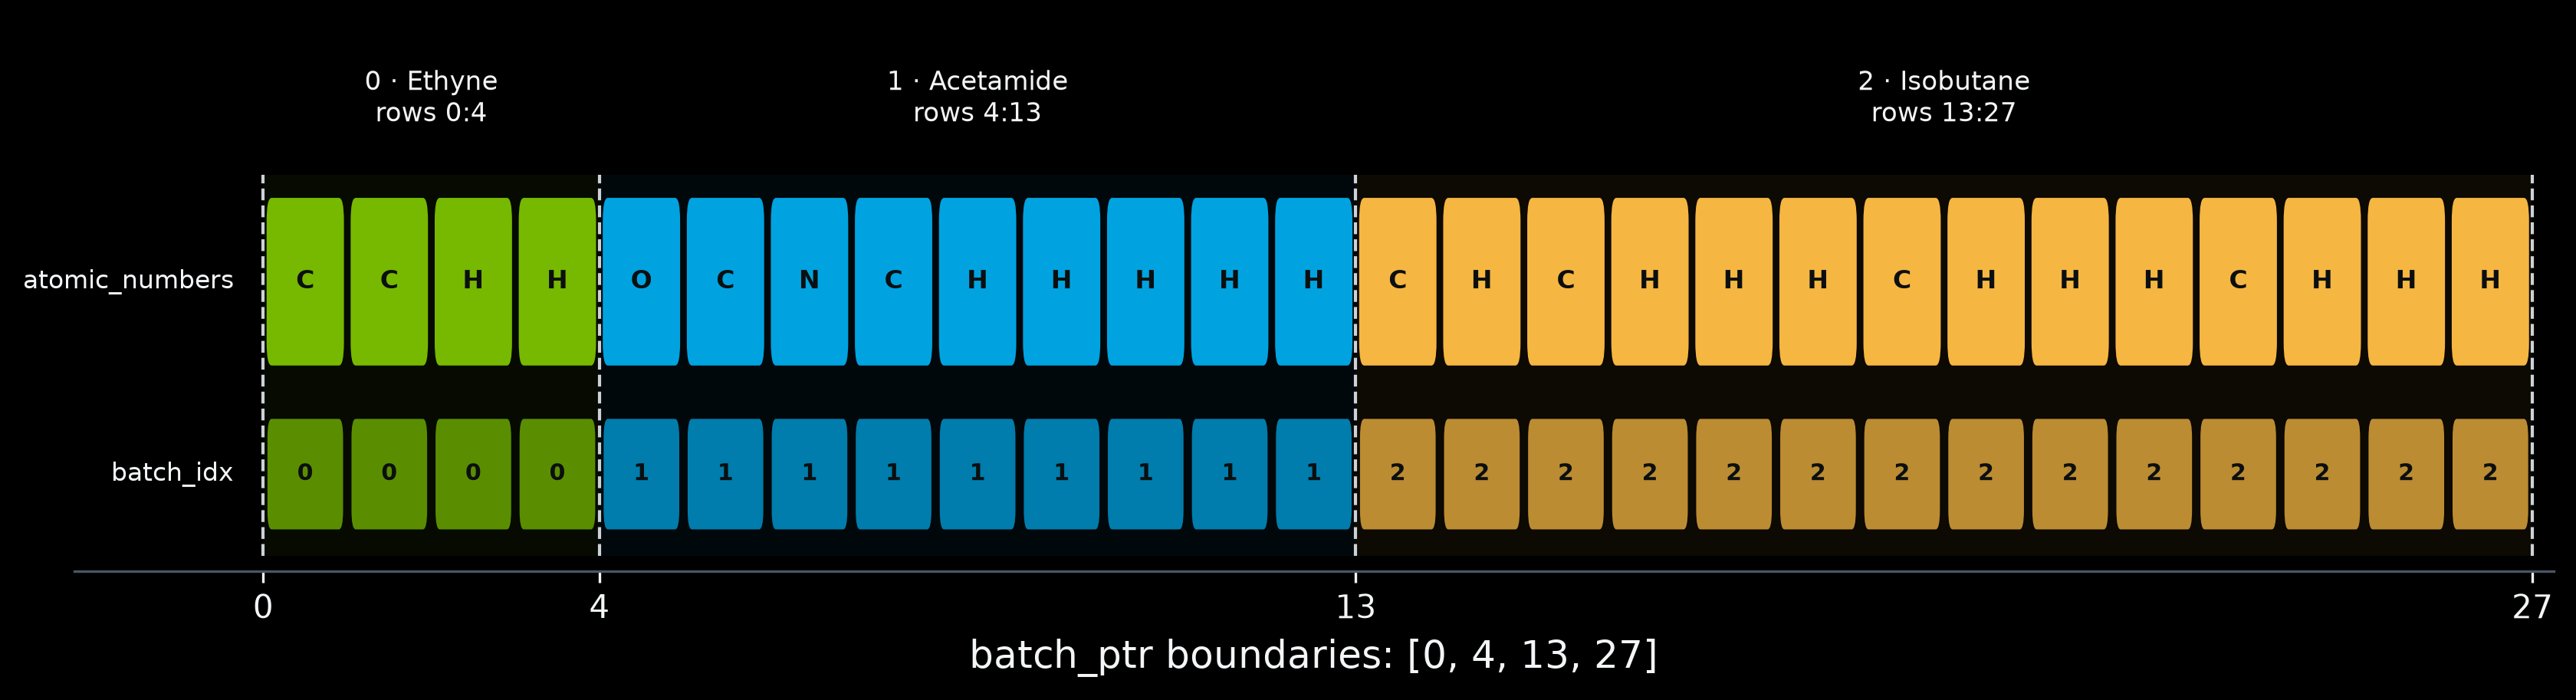

In [22]:
helpers.plot_batch_ownership(example_batch, labels)

#### Index a `Batch`

A `Batch` packs several atomic systems. Integer indexing returns one system as an `AtomicData`; slicing returns a smaller `Batch`. Use `range(len(batch))` to visit each system.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `batch[index]`
>
> **Input:** an integer position or slice  
> **Result:** one `AtomicData` or a smaller `Batch`

In [23]:
graph_index = 2
selected_molecule = example_batch[graph_index]
print(selected_molecule)

atomic_numbers=tensor([6, 1, 6, 1, 1, 1, 6, 1, 1, 1, 6, 1, 1, 1], device='cuda:0',
       dtype=torch.int32) positions=tensor([[ 0.0000,  0.0000,  0.3769],
        [ 0.0000,  0.0000,  1.4753],
        [ 0.0000,  1.4503, -0.0962],
        [ 0.0000,  1.4940, -1.1908],
        [-0.8855,  1.9847,  0.2613],
        [ 0.8855,  1.9847,  0.2613],
        [ 1.2560, -0.7251, -0.0962],
        [ 1.2938, -0.7470, -1.1908],
        [ 2.1615, -0.2255,  0.2613],
        [ 1.2761, -1.7592,  0.2613],
        [-1.2560, -0.7251, -0.0962],
        [-1.2938, -0.7470, -1.1908],
        [-1.2761, -1.7592,  0.2613],
        [-2.1615, -0.2255,  0.2613]], device='cuda:0') atomic_masses=tensor([12.0110,  1.0080, 12.0110,  1.0080,  1.0080,  1.0080, 12.0110,  1.0080,
         1.0080,  1.0080, 12.0110,  1.0080,  1.0080,  1.0080], device='cuda:0') atom_categories=tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0') neighbor_list=None shifts=None neighbor_list_shifts=None neighbor_matrix=None neighbor_

In [24]:
for index in range(len(example_batch)):
    structure_data = example_batch[index]
    print(index, structure_data)

0 atomic_numbers=tensor([6, 6, 1, 1], device='cuda:0', dtype=torch.int32) positions=tensor([[ 0.0000,  0.0000,  0.6081],
        [ 0.0000,  0.0000, -0.6081],
        [ 0.0000,  0.0000, -1.6740],
        [ 0.0000,  0.0000,  1.6740]], device='cuda:0') atomic_masses=tensor([12.0110, 12.0110,  1.0080,  1.0080], device='cuda:0') atom_categories=tensor([0, 0, 0, 0], device='cuda:0') neighbor_list=None shifts=None neighbor_list_shifts=None neighbor_matrix=None neighbor_matrix_shifts=None num_neighbors=None cell=None pbc=None forces=None energy=None stress=None virial=None dipole=None charges=None charge=tensor([[0.]], device='cuda:0') node_attrs=None node_alpha_spins=None node_beta_spins=None spin=None graph_alpha_spins=None node_embeddings=None edge_embeddings=None graph_embeddings=None velocities=tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], device='cuda:0') momenta=None kinetic_energies=None info={} __node_keys__={'velocities', 'atomic_numbers', '

> 💡 `batch[i]` returns one system as an `AtomicData`; integer indexing calls `get_data(i)` internally. A slice such as `batch[1:3]` returns another `Batch`.

**Toolkit reference:** [AtomicData and Batch](https://nvidia.github.io/nvalchemi-toolkit/examples/basic/01_data_structures.html)

### Compare individual and batched model calls

The helper repeats the ethyne structure from the start of the lesson. It loads AIMNet2 on CPU and GPU, requests energy and forces, prepares neighbors, and runs each route once without timing it. The reported time then covers individual model calls or one `Batch` call on already-built neighbor data. Model loading, conversion, batching, neighbor construction, and the first untimed call stay outside the timer.

Each route is measured once in this playbook, so the result is a batching demonstration for this hardware. Part 06 adds repeated measurements, spread, transfers, compilation, and profiling. A CPU-only walkthrough uses 128 copies.

In [25]:
BENCHMARK_MOLECULES = 2_048 if device.type == "cuda" else 128
batching_results = helpers.benchmark_repeated_molecule(
    ethyne, batch_size=BENCHMARK_MOLECULES, device=device
)

/tmp/alchemi-v3-runtime/venv/lib/python3.12/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [26]:
print(f"Timed after one untimed model call | energy + forces | {BENCHMARK_MOLECULES:,} ethyne molecules")
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(device))
print(f"{'route':18} {'time [s]':>10} {'molecules/s':>13} {'peak allocated [MiB]':>21}")
for row in batching_results:
    memory = row["peak memory [MiB]"]
    memory_text = "n/a" if memory is None else f"{memory:,.0f}"
    print(
        f"{row['mode']:18} {row['seconds']:>10.2f} "
        f"{row['molecules/s']:>13,.0f} {memory_text:>21}"
    )
batch_row = next(row for row in reversed(batching_results) if row["route"] == "Batch")
print(f"Batch outputs | energy {batch_row['energy shape']} | forces {batch_row['forces shape']}")

Timed after one untimed model call | energy + forces | 2,048 ethyne molecules
GPU: NVIDIA RTX 4000 SFF Ada Generation
route                time [s]   molecules/s  peak allocated [MiB]
CPU · individual        10.48           195                   n/a
GPU · individual        20.84            98                    26
CPU · Batch              0.64         3,202                   n/a
GPU · Batch              0.06        32,735                   366
Batch outputs | energy (2048, 1) | forces (8192, 3)



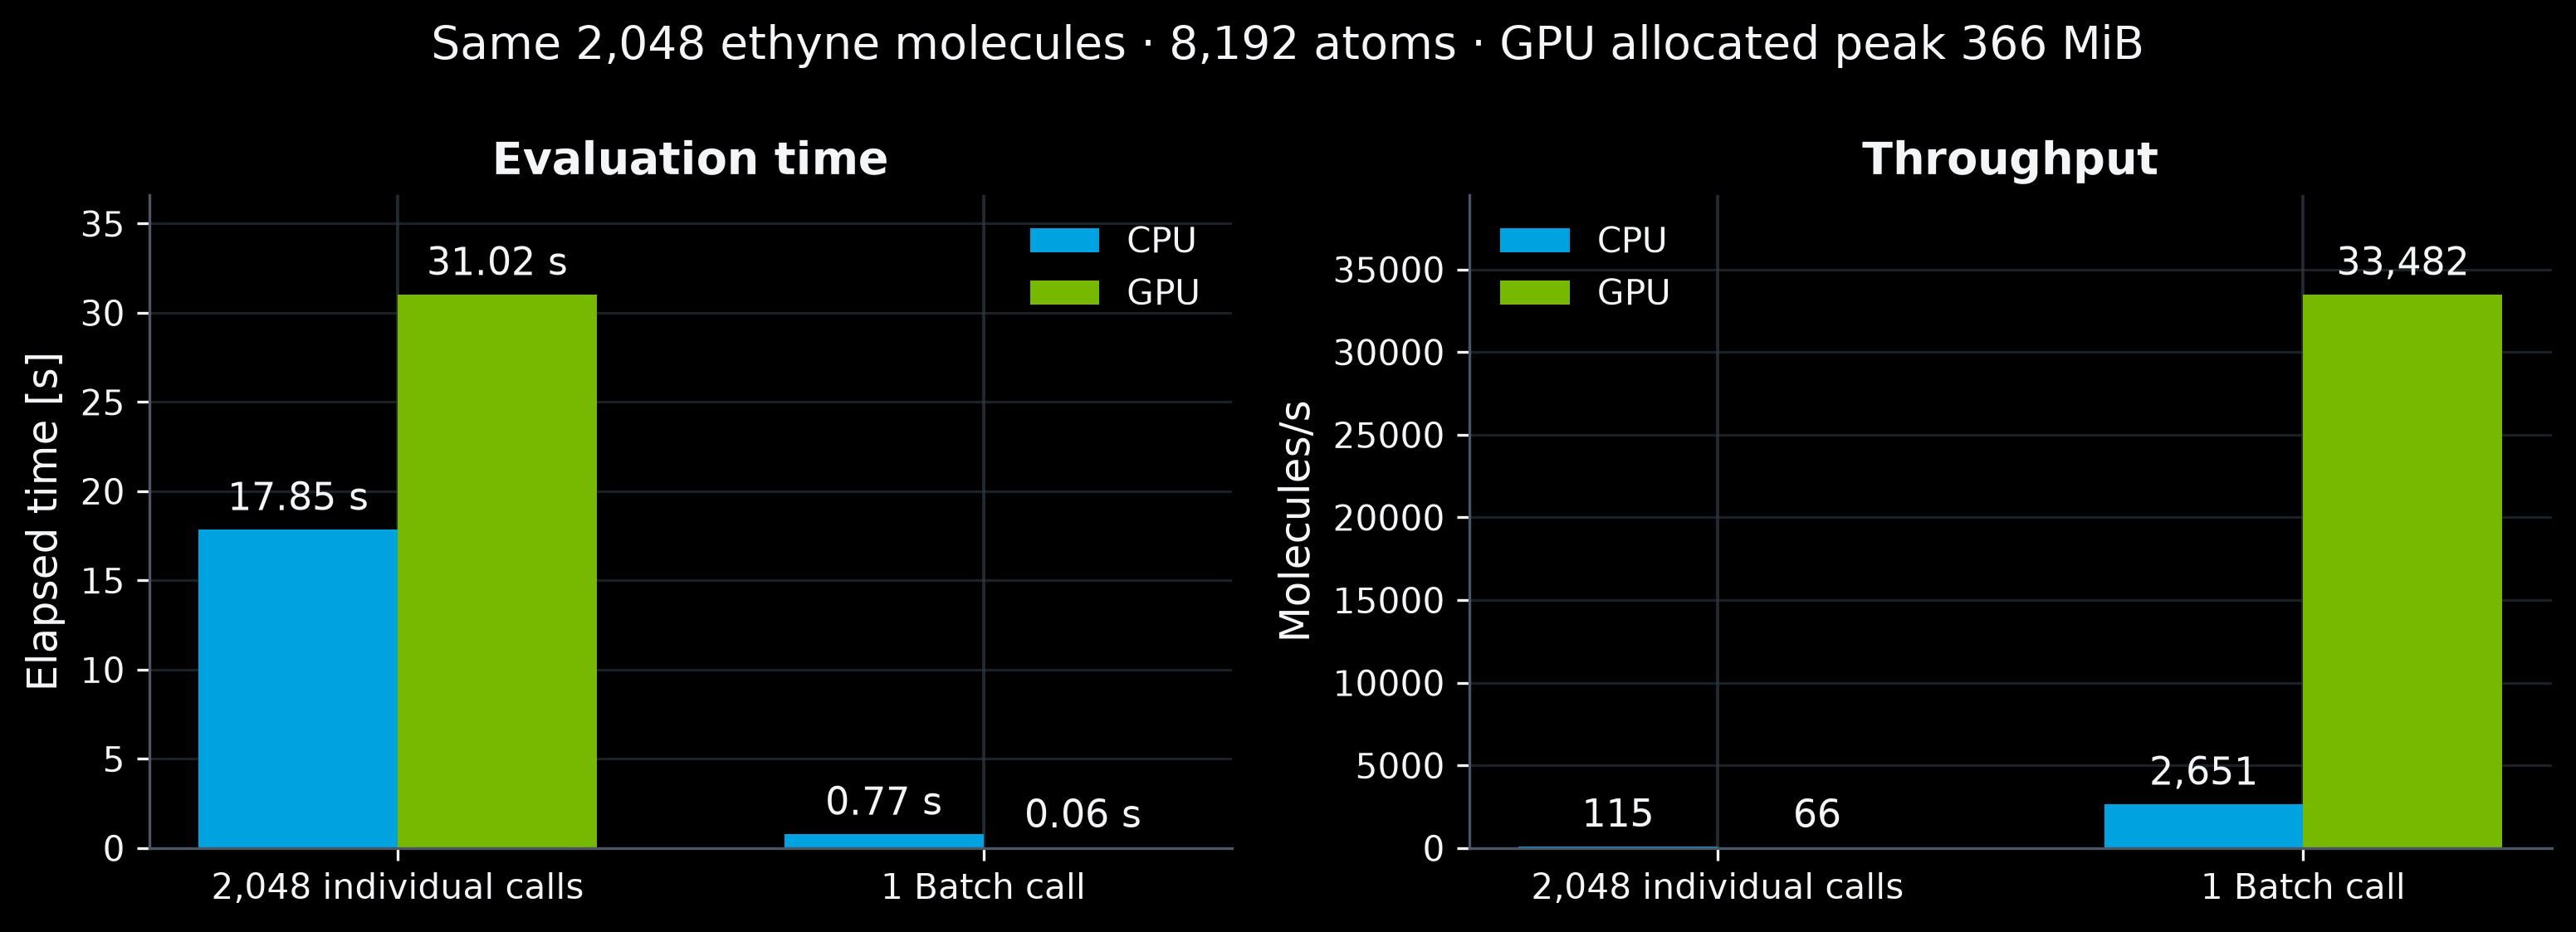

In [26]:
helpers.plot_batching_benchmark(batching_results)

Compare CPU and GPU within each call shape, then compare individual calls with one `Batch` call on the same device. The bars report one timing per route after an untimed first call for this workload and hardware. 

> 💡 `Batch` keeps molecules with different atom counts together. `batch_ptr` shows where each molecule starts and ends; `batch_idx` shows which molecule owns each atom row.

<hr class="alchemi-section-divider" aria-hidden="true" style="border:0;border-top:1px solid #D6D9D4;margin:2.4rem 0 1rem;">

## 04 · Save `AtomicData` and load model batches

A `Batch` lives in memory and can grow quickly. [Zarr arrays](https://zarr.readthedocs.io/en/stable/user-guide/arrays/) store chunked array data. Toolkit's Zarr writer also records atom and edge boundaries so each variable-size structure can be recovered.

The benchmark above starts from one in-memory `Batch`. The next cells save its three `AtomicData` records, repeat them to make a 12-record loading example, and rebuild model batches on the selected device.

<img src="assets/zarr-data-flow-1dd43fe6aaf828cf.svg" alt="A Zarr store supplies raw CPU tensors through Reader. Dataset validates and moves records to the selected device. DataLoader collates them into a Batch that stays on that device." style="display:block;box-sizing:border-box;width:100%;max-width:920px;height:auto;margin:0.8rem 0 0.45rem;">


In [27]:
# Move the packed tensors to CPU once, then recover the individual molecules.
records_to_save = example_batch.to(torch.device("cpu")).to_data_list()

In [28]:
print(f"{'record':>6} {'molecule':12} {'atoms':>5} {'device':>7}")
for index, (record, label) in enumerate(zip(records_to_save, labels, strict=True)):
    print(f"{index:>6} {label:12} {record.num_nodes:>5} {str(record.device):>7}")

record molecule     atoms  device
     0 Ethyne           4     cpu
     1 Acetamide        9     cpu
     2 Isobutane       14     cpu


In [29]:
STORE = Path(tempfile.mkdtemp(prefix="alchemi-core-zarr-")) / "molecules.zarr"
writer = AtomicDataZarrWriter(STORE)

### Write one record, then append two more

`write(...)` creates a new store. `append(...)` adds records to that store. An open reader caches the store index, so `reader.refresh()` reloads that index after the writer adds records.

This tutorial uses its own temporary path. Rerun this section from the store-creation cell to start from an empty store. For a larger write, pass a list of `AtomicData` records or a `Batch` so Toolkit can combine the I/O.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `writer.write(records)`
>
> **Input:** one `AtomicData`, a list of records, or a `Batch`  
> **Result:** a new Zarr store containing fields and per-record boundaries

In [35]:
if STORE.exists():
    shutil.rmtree(STORE)  # Reset this tutorial's temporary store.
writer.write(records_to_save[0])

In [36]:
reader = AtomicDataZarrReader(STORE)
print(f"After write:  {len(reader)} stored structure")

After write:  1 stored structure


In [37]:
writer.append(records_to_save[1:])
reader.refresh()  # Reload the open reader after the store changes.

In [38]:
print(f"After append: {len(reader)} stored structures")

After append: 3 stored structures


In [39]:
print("Stored field ownership")
for field, level in sorted(reader.field_levels.items()):
    print(f"  {field:18} {level}")

Stored field ownership
  atom_categories    atom
  atomic_masses      atom
  atomic_numbers     atom
  charge             system
  positions          atom
  velocities         atom


### Inspect boundaries from metadata

`get_metadata(index)` reports the stored atom and edge counts. A loader or sampler can use these sizes before it materializes a complete record.

In [40]:
print(f"{'record':>6} {'atoms':>6} {'edges':>6}")
for index in range(len(reader)):
    atom_count, edge_count = reader.get_metadata(index)
    print(f"{index:>6} {atom_count:>6} {edge_count:>6}")

record  atoms  edges
     0      4      0
     1      9      0
     2     14      0


### Read raw CPU tensors

`AtomicDataZarrReader.read(...)` returns a tensor dictionary plus metadata. This is the storage boundary. `Dataset` will turn the dictionary back into a validated `AtomicData`.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `fields, metadata = reader.read(index)`
>
> **Input:** one logical record index  
> **Result:** a raw CPU tensor dictionary plus record metadata

In [41]:
raw_record, raw_metadata = reader.read(1)
print(f"object:    {type(raw_record).__name__}")
print(f"keys:      {sorted(raw_record)}")
print(f"positions: {tuple(raw_record['positions'].shape)} on {raw_record['positions'].device}")
print(f"metadata:  {raw_metadata}")

object:    dict
keys:      ['atom_categories', 'atomic_masses', 'atomic_numbers', 'charge', 'positions', 'velocities']
positions: (9, 3) on cpu
metadata:  {'index': 1, 'source_file': '/tmp/alchemi-core-zarr-w4068a2c/molecules.zarr', 'physical_index': '1'}


### Request several records in a chosen order

`read_many(...)` preserves the requested logical order. The reader can group physical I/O internally when that helps the backend.

In [42]:
requested = [2, 0]
loaded_records = reader.read_many(requested)

In [43]:
print("requested order:", requested)
print(
    "loaded atom counts:",
    [len(raw["atomic_numbers"]) for raw, _ in loaded_records],
)

requested order: [2, 0]
loaded atom counts: [14, 4]


### Load `AtomicData` onto the compute device

`Dataset` validates each reader result, applies optional sample transforms, and moves the resulting `AtomicData` to its target device. `num_workers` controls how many reader threads fetch records.

In [44]:
dataset = Dataset(
    reader,
    device=device,
    num_workers=1,  # One reader thread is enough for this three-record example, increase for large datasets
)
len(dataset)

3

In [45]:
validated_record, validated_metadata = dataset[1]

In [46]:
print(f"object:   {type(validated_record).__name__}")
print(f"atoms:    {validated_record.num_nodes}")
print(f"device:   {validated_record.device}")
print(f"metadata: {validated_metadata}")

object:   AtomicData
atoms:    9
device:   cuda:0
metadata: {'index': 1, 'source_file': '/tmp/alchemi-core-zarr-w4068a2c/molecules.zarr', 'physical_index': '1'}


A Zarr schema calls per-node storage the **atom** level. `AtomicData` and `Batch` expose the same ownership as the **node** level.

`Dataset` and `DataLoader` work with any Toolkit `Reader`. Part 02 implements readers for other storage backends and shows when grouped reads improve I/O.

### Load and prefetch `Batch` objects

`DataLoader` groups `Dataset` records into the `Batch` objects consumed by models. Repeat our three unequal structures four times so the read window contains several model batches.

| setting | value |
|---|---:|
| stored structures | 12 |
| `batch_size` | 3 structures |
| emitted model batches | 4 |
| `prefetch_factor` | 2 batches |
| maximum backend read | 6 structures |

```text
model batches:  [0 1 2] [3 4 5] | [6 7 8] [9 10 11]
backend reads:  [---- 0..5 ---] | [---- 6..11 ----]
```

`batch_size=3` controls what the model receives: four `Batch` objects with three structures each. `prefetch_factor=2` controls storage I/O: Toolkit combines two upcoming batches into each background `read_many(...)` call. The effective read window is `3 × 2 = 6` structures. Each window is split back into the original three-structure batches before they are yielded.

Toolkit keeps the next read window queued while the caller works on ready batches. `prefetch_factor=0` selects synchronous loading. Part 02 profiles background reads, pinned memory, and CUDA streams on a representative store.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `DataLoader(dataset, batch_size=..., prefetch_factor=..., use_streams=...)`
>
> **Input:** a Toolkit `Dataset` and batching or prefetch settings  
> **Result:** an iterator that yields model-ready `Batch` objects

In [47]:
prefetch_records = records_to_save * 4
reader.refresh()
if len(reader) < len(prefetch_records):
    writer.append(prefetch_records[len(reader):])
reader.refresh()

In [48]:
loader = DataLoader(
    dataset, batch_size=3, shuffle=False, prefetch_factor=2,
    use_streams=device.type == "cuda",
)
print(f"{len(dataset)} structures → {len(loader)} model batches")
print(f"up to {loader.effective_read_window} structures per backend read")

12 structures → 4 model batches
up to 6 structures per backend read


In [49]:
# Convert this small loader to a list so the next cells can inspect every batch.
loaded_batches = list(loader)

In [50]:
print(f"{'batch':>5} {'graphs':>6} {'atoms':>6} {'boundaries':>16} {'device':>8}")
for index, batch in enumerate(loaded_batches):
    print(
        f"{index:>5} {batch.num_graphs:>6} {batch.num_nodes:>6} "
        f"{str(batch.batch_ptr.tolist()):>16} {str(batch.device):>8}"
    )

batch graphs  atoms       boundaries   device
    0      3     27   [0, 4, 13, 27]   cuda:0
    1      3     27   [0, 4, 13, 27]   cuda:0
    2      3     27   [0, 4, 13, 27]   cuda:0
    3      3     27   [0, 4, 13, 27]   cuda:0


In [51]:
dataset.close()
shutil.rmtree(STORE.parent)
print("Temporary Zarr store removed.")

Temporary Zarr store removed.


`loaded_batches` now holds four graph-aware `Batch` objects on the selected device. We will keep the first one and ask AIMNet2 for one energy per molecule and one force vector per atom.

**Go deeper:** <span class="alchemi-in-progress">Part 02 · Data loading with Zarr · in progress</span>. This lesson implements a custom reader and studies compression, chunking, transforms, prefetching, streams, caches, and size-aware sampling. The [official Zarr trajectory example](https://nvidia.github.io/nvalchemi-toolkit/examples/intermediate/02_trajectory_zarr_io.html) connects `SnapshotHook` storage to the same reader and loader path.

> 💡 `Reader` reads stored tensors, `Dataset` turns one record into `AtomicData`, and `DataLoader` groups records into the `Batch` a model receives.

<hr class="alchemi-section-divider" aria-hidden="true" style="border:0;border-top:1px solid #D6D9D4;margin:2.4rem 0 1rem;">

## 05 · Do forward pass (get energies and forces) and swap pretrained models

Data loading produced the model input: `loaded_batches[0]`. `AIMNet2Wrapper` exposes an [AIMNet2 model](https://doi.org/10.1039/D4SC08572H) - powerful MLIP for organic molecules - through Toolkit's interface. We load pinned `aimnet2_wb97m_d3_0` checkpoint from the [official AIMNet2 wB97M-D3 model card](https://huggingface.co/isayevlab/aimnet2-wb97m-d3). 

Load the wrapper, inspect the inputs and outputs it declares, prepare its requested neighbors, then evaluate the loaded batch.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `AIMNet2Wrapper.from_checkpoint(checkpoint, device=device)`
>
> **Input:** a supported AIMNet2 checkpoint and target device  
> **Result:** a Toolkit model wrapper with declared inputs, outputs, and neighbor requirements

In [52]:
model = AIMNet2Wrapper.from_checkpoint(
    "aimnet2-wb97m-d3_0",
    device=device,
    compile_model=False,
)

model = model.eval() #set to inference mode
model.requires_grad_(False) # freeze weights; forces still use position gradients.

AIMNet2Wrapper(
  outputs={charges, energy, forces, stress}
  active_outputs={charges, energy, forces}
  autograd_outputs={forces, stress}
  required_inputs={charge}
  optional_inputs={cell, mult}
  pbc=[supports_pbc]
  neighbors=(cutoff=5.0, format=matrix)
  (model): AIMNet2(
    (aev): AEVSV()
    (afv): Embedding(64, 16, padding_idx=0)
    (conv_a): ConvSV()
    (conv_q): ConvSV()
    (mlps): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=704, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=380, bias=True)
        (3): GELU(approximate='none')
        (4): Linear(in_features=380, out_features=258, bias=True)
      )
      (1): Sequential(
        (0): Linear(in_features=733, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=380, bias=True)
        (3): GELU(approximate='none')
        (4): Linear(in_features=380, out_features=258

In [53]:
print("wrapper:          ", type(model).__name__)
print("device:           ", next(model.parameters()).device)
print("required inputs:  ", sorted(model.input_data()))
print("available outputs:", sorted(model.model_config.outputs))
print("periodic support: ", model.model_config.supports_pbc)

wrapper:           AIMNet2Wrapper
device:            cuda:0
required inputs:   ['atomic_numbers', 'charge', 'neighbor_matrix', 'num_neighbors', 'positions']
available outputs: ['charges', 'energy', 'forces', 'stress']
periodic support:  True


### Choose outputs and prepare neighbors

`active_outputs` is a set of result names requested for the next call. Set order does not affect the calculation. Energy has one row per molecule; forces have one three-component row per atom.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `model.set_config("active_outputs", {"energy", "forces"})`
>
> **Input:** a model wrapper and supported output names  
> **Result:** the same wrapper with its requested outputs updated for later calls

A neighbor list tells the model which atom pairs can interact. `NeighborConfig.cutoff` is required, and each model wrapper supplies its own value. This AIMNet2 checkpoint declares:

- `cutoff=5.0 Å`: each atom's local environment includes atoms up to 5 Å away;
- `format=MATRIX`: store their indices as `[atoms, max_neighbors]`;
- `half_list=False`: keep both pair directions; and
- `skin=0.0 Å`: use no extra Verlet buffer.

For this standalone call, use the model's `neighbor_config`; it supplies the cutoff, format, and pair convention. The call builds neighbors once at the current coordinates.

During dynamics, a positive `skin` builds to `cutoff + skin` and reuses the list until an atom moves more than `skin / 2`. The default `skin=0.0 Å` rebuilds every step and is fine for this lesson; longer runs may benefit from a benchmarked positive value.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `compute_neighbors(batch, config=neighbor_config)`
>
> **Input:** a `Batch` and the model's neighbor configuration  
> **Result:** neighbor fields added to that `Batch`

In [54]:
# Choose the outputs needed for this forward pass.
model.set_config("active_outputs", {"energy", "forces"})
# Read the neighbor requirement declared by the AIMNet2 wrapper.
neighbor_config = model.model_config.neighbor_config
model.model_config.active_outputs, neighbor_config

({'energy', 'forces'},
 NeighborConfig(cutoff=5.0, format=<NeighborListFormat.MATRIX: 'matrix'>, half_list=False, skin=0.0))

In [55]:
model_batch = loaded_batches[0]
print("Loaded model batch")
print("  graphs:", model_batch.num_graphs)
print("  atoms: ", model_batch.num_nodes)
print("  device:", model_batch.device)
print("  neighbor_matrix:", getattr(model_batch, "neighbor_matrix", None))

Loaded model batch
  graphs: 3
  atoms:  27
  device: cuda:0
  neighbor_matrix: None


In [56]:
# Standalone inference prepares neighbors once at the current coordinates.
neighbor_return = compute_neighbors(model_batch, config=neighbor_config)
print("return value:", neighbor_return)  # None: model_batch changed in place.

return value: None


In [57]:
print("Batch fields after compute_neighbors")
print("  neighbor_matrix:", tuple(model_batch.neighbor_matrix.shape))
print("  num_neighbors:  ", tuple(model_batch.num_neighbors.shape))
print("  format:         ", model.model_config.neighbor_config.format.name)

Batch fields after compute_neighbors
  neighbor_matrix: (27, 16)
  num_neighbors:   (27,)
  format:          MATRIX


### Run one batched forward pass

Before running the model, predict the output shapes. Energy has one row per graph. Forces have one three-component row per atom.

Run the next two cells, then compare the returned shapes with `num_graphs` and `num_nodes`.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `outputs = model(batch)`
>
> **Input:** a neighbor-prepared `Batch`  
> **Result:** a separate `ModelOutputs` mapping with the requested quantities

In [58]:
# one model call returns energies for all systems and forces for all atoms in the Batch.
model_output = model(model_batch)

In [59]:
# model predictions are returned separately from the input Batch.
print("Batch fields:", "energy" in model_batch, "forces" in model_batch)
print("Returned fields:", sorted(model_output))

Batch fields: False False
Returned fields: ['energy', 'forces']


In [60]:
print("returned outputs:", model_output)

returned outputs: OrderedDict({'energy': tensor([[-2104.4020],
        [-5687.7648],
        [-4312.4281]], device='cuda:0', dtype=torch.float64,
       grad_fn=<UnsqueezeBackward0>), 'forces': tensor([[-0.0000e+00, -0.0000e+00, -5.5947e+00],
        [-0.0000e+00, -0.0000e+00,  5.5947e+00],
        [-0.0000e+00, -0.0000e+00, -9.8387e-01],
        [-0.0000e+00, -0.0000e+00,  9.8387e-01],
        [ 2.9583e-01,  2.6162e+00, -9.3183e-02],
        [ 3.3685e+00, -3.4356e+00,  2.0017e-01],
        [-2.8066e+00,  2.1237e+00, -1.2247e+00],
        [-3.1999e-02,  1.0838e-01,  1.5630e-03],
        [-1.1953e+00, -2.1785e+00,  5.7145e-01],
        [-4.3595e-01,  3.8068e-02, -3.1438e-02],
        [-5.7296e-01, -3.3444e-01, -2.1534e-01],
        [-6.2892e-01, -3.6589e-01,  2.9581e-01],
        [ 2.0074e+00,  1.4280e+00,  4.9562e-01],
        [ 1.6764e-07, -3.8743e-06, -7.0530e-01],
        [-2.4796e-08,  1.4352e-07,  2.5091e-01],
        [ 2.3703e-08, -6.5200e-01,  2.5254e-01],
        [-2.6690e-08, 

In [61]:
print("energy:", model_output["energy"].shape, model_output["energy"].dtype, "eV")
print("forces:", model_output["forces"].shape, model_output["forces"].dtype, "eV/Å")
print("graphs:", model_batch.num_graphs, "| atoms:", model_batch.num_nodes)
print("device:", model_output["forces"].device)

energy: torch.Size([3, 1]) torch.float64 eV
forces: torch.Size([27, 3]) torch.float32 eV/Å
graphs: 3 | atoms: 27
device: cuda:0


### Exercise · Call MACE on the same `Batch`

> ✏️ **TRY IT**
>
> Use the checkpoint `medium-0b2` to create a MACE wrapper. Clone `model_batch`, prepare the clone with MACE's neighbor configuration, and call the wrapper.
>
> Store the three objects as `mace`, `mace_batch`, and `mace_output`. The check below should print the wrapper, neighbor format, and output shapes.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `MACEWrapper.from_checkpoint(...)`
>
> **Input:** a MACE checkpoint and target device  
> **Result:** a Toolkit model wrapper

In [62]:
mace_checkpoint = "medium-0b2"

# Create `mace`, prepare `mace_batch`, and assign `mace_output`.
# Write your code below.

In [ ]:
# Run this check after completing the exercise.
if not {"mace", "mace_output"}.issubset(globals()):
    print("Complete the exercise cell, then run this check again.")
else:
    print("wrapper:", type(mace).__name__)
    print("neighbors:", mace.model_config.neighbor_config.format.name)
    print("energy:", mace_output["energy"].shape)
    print("forces:", mace_output["forces"].shape)

<details>
<summary>Show a sample solution</summary>

```python
from nvalchemi.models import MACEWrapper

mace = MACEWrapper.from_checkpoint(mace_checkpoint, device=device).eval()
mace_batch = model_batch.clone()
compute_neighbors(mace_batch, config=mace.model_config.neighbor_config)
mace_output = mace(mace_batch)
```

</details>

MACE returns energy for each system and forces for each atom. Its COO neighbors are prepared on `mace_batch`, so `model_batch` keeps the AIMNet2 neighbor fields.

> 💡 Toolkit also provides `UMAWrapper` for UMA task heads; `LennardJonesModelWrapper`, `DFTD3ModelWrapper`, `EwaldModelWrapper`, and `PMEModelWrapper` for classical and physical terms; and `PipelineModelWrapper` for composition. See the [models guide](https://nvidia.github.io/nvalchemi-toolkit/userguide/models.html) and [MACE example](https://nvidia.github.io/nvalchemi-toolkit/examples/advanced/04_mace_nvt.html).

<hr class="alchemi-section-divider" aria-hidden="true" style="border:0;border-top:1px solid #D6D9D4;margin:2.4rem 0 1rem;">

## 06 · Observe and protect a simulation with hooks

A forward pass evaluates one set of coordinates. During molecular dynamics or geometry optimization, the coordinates change and the model must evaluate each new state. **Hooks** run small actions at named stages of that workflow and at a chosen frequency.

This section combines four actions:

- model-supplied neighbor hooks prepare the neighbor list before prediction;
- `NaNDetectorHook` stops the workflow if energy or forces become non-finite;
- a custom `ForceHistoryHook` records energy and maximum force;
- `SnapshotHook` saves periodic copies of the batch to host memory.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `neighbor_hooks = model.make_neighbor_hooks()`
>
> **Input:** a configured model wrapper  
> **Result:** model-specific hooks that prepare the required neighbor fields during an iterative workflow

Toolkit also provides `LoggingHook` for scalar records, `ConvergenceHook` for detecting completed systems, and `ConvergedSnapshotHook` for saving structures when they converge. `StageTimingHook` and `TorchProfilerHook` help measure workflow performance.

In [64]:
neighbor_hooks = model.make_neighbor_hooks()

In [65]:
MAX_STEPS = 16
SNAPSHOT_EVERY = 4

# Batch exposes its number of packed systems through num_graphs.
SYSTEMS_IN_BATCH = example_batch.num_graphs
SNAPSHOTS_PER_SYSTEM = MAX_STEPS // SNAPSHOT_EVERY
SNAPSHOT_CAPACITY = SYSTEMS_IN_BATCH * SNAPSHOTS_PER_SYSTEM

# Check energy and forces after every model evaluation.
nan_guard = NaNDetectorHook(frequency=1)

# Every fourth step, copy one snapshot per system into CPU memory.
snapshot_sink = HostMemory(capacity=SNAPSHOT_CAPACITY)
snapshot_hook = SnapshotHook(sink=snapshot_sink, frequency=SNAPSHOT_EVERY)

In [66]:
print("NaN guard checks every step")
print(
    f"Snapshots: {SNAPSHOTS_PER_SYSTEM} per system × "
    f"{SYSTEMS_IN_BATCH} systems = {SNAPSHOT_CAPACITY} stored structures"
)
print(f"Snapshot interval: every {SNAPSHOT_EVERY} steps")

NaN guard checks every step
Snapshots: 4 per system × 3 systems = 12 stored structures
Snapshot interval: every 4 steps


### Add one small observer

A custom hook declares its stage and frequency, then receives the current `DynamicsContext`. `AFTER_COMPUTE` is the point where energy and forces are ready on `ctx.batch`.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> ```python
> class ObserverHook:
>     stage = DynamicsStage.AFTER_COMPUTE
>     frequency = 1
> 
>     def __call__(self, ctx: DynamicsContext, stage: DynamicsStage):
>         ...
> ```
>
> **Input:** the current `DynamicsContext` and lifecycle stage  
> **Result:** a hook the workflow registry dispatches at the declared stage and frequency

In [ ]:
class ForceHistoryHook:
    stage = DynamicsStage.AFTER_COMPUTE
    frequency = 1

    def __init__(self):
        self.rows = []

    def __call__(self, ctx: DynamicsContext, stage: DynamicsStage):
        if ctx.batch is None:
            raise RuntimeError("ForceHistoryHook requires a populated Batch")
        pointers = ctx.batch.batch_ptr.tolist()
        for graph, (start, stop) in enumerate(zip(pointers[:-1], pointers[1:], strict=True)):
            # Detach recorded values and move them to CPU before adding them to the history.
            forces = ctx.batch.forces[start:stop].detach()
            self.rows.append({
                "step": int(ctx.step_count),
                "graph": graph,
                "energy_ev": float(ctx.batch.energy[graph].detach().sum().cpu()),
                "fmax_ev_per_a": float(forces.norm(dim=1).max().cpu()),
            })

In [ ]:
history_hook = ForceHistoryHook()
workflow_hooks = [
    *neighbor_hooks,
    nan_guard,
    history_hook,
    snapshot_hook,
]

NameError: name 'ForceHistoryHook' is not defined

In [ ]:
print(f"{'hook':24} {'stage':18} {'every':>5}")
for hook in workflow_hooks:
    print(f"{type(hook).__name__:24} {hook.stage.name:18} {hook.frequency:>5}")

hook                     stage              every
NeighborListHook         BEFORE_COMPUTE         1
NaNDetectorHook          AFTER_COMPUTE          1
ForceHistoryHook         AFTER_COMPUTE          1
SnapshotHook             AFTER_STEP             4


In [ ]:
relaxation_input = helpers.prepare_dynamics_batch(model_batch)
print("Before the workflow")
print("  neighbor_matrix:", getattr(relaxation_input, "neighbor_matrix", None))
print("  num_neighbors:  ", getattr(relaxation_input, "num_neighbors", None))

Before the workflow
  neighbor_matrix: tensor([[ 1,  2,  3, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27],
        [ 0,  2,  3, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27],
        [ 0,  1,  3, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27],
        [ 0,  1,  2, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27],
        [ 5,  6,  7,  8,  9, 10, 11, 12, 27, 27, 27, 27, 27, 27, 27, 27],
        [ 4,  6,  7,  8,  9, 10, 11, 12, 27, 27, 27, 27, 27, 27, 27, 27],
        [ 4,  5,  7,  8,  9, 10, 11, 12, 27, 27, 27, 27, 27, 27, 27, 27],
        [ 4,  5,  6,  8,  9, 10, 11, 12, 27, 27, 27, 27, 27, 27, 27, 27],
        [ 4,  5,  6,  7,  9, 10, 11, 12, 27, 27, 27, 27, 27, 27, 27, 27],
        [ 4,  5,  6,  7,  8, 10, 11, 12, 27, 27, 27, 27, 27, 27, 27, 27],
        [ 4,  5,  6,  7,  8,  9, 11, 12, 27, 27, 27, 27, 27, 27, 27, 27],
        [ 4,  5,  6,  7,  8,  9, 10, 12, 27, 27, 27, 27, 27, 27, 27, 27],
        [ 4,  5,  6,  7,  8,  9, 10, 11, 27, 27, 27, 27, 27, 27, 27, 27],

`system_id` gives each molecule a stable label that travels with its graph through FIRE2 and into saved results.

In [ ]:
MOLECULE_IDS = (101, 102, 103)
relaxation_input.add_key(
    "system_id",
    [torch.tensor([value], dtype=torch.long) for value in MOLECULE_IDS],
    level="system",
)

### Trigger the NaN safety hook

This probe uses the same workflow dispatcher as a simulation, but runs on a separate `Batch`. At `AFTER_COMPUTE`, hooks run in registration order:

1. `InjectNaNHook` changes one computed force to `NaN`.
2. `NaNDetectorHook` inspects the forces and stops the step.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `NaNDetectorHook(frequency=1)`
>
> **Input:** a hook frequency  
> **Result:** a workflow guard that raises when computed energy or forces are non-finite

In [ ]:
class InjectNaNHook:
    stage = DynamicsStage.AFTER_COMPUTE
    frequency = 1

    def __call__(self, ctx: DynamicsContext, stage: DynamicsStage):
        ctx.batch.forces[0, 0] = torch.nan

In [ ]:
nan_probe = helpers.prepare_dynamics_batch(model_batch)
nan_probe_hooks = [
    *model.make_neighbor_hooks(),
    InjectNaNHook(),
    NaNDetectorHook(),
]
nan_probe_workflow = BaseDynamics(model=model, n_steps=1, hooks=nan_probe_hooks)

In [ ]:
try:
    nan_probe_workflow.run(nan_probe)
except RuntimeError as error:
    print("InjectNaNHook -> NaNDetectorHook")
    print(str(error).splitlines()[0])
else:
    raise RuntimeError("NaNDetectorHook did not fire")

InjectNaNHook -> NaNDetectorHook
Non-finite values detected at step 0 in field(s): ['forces']


The workflow reached `AFTER_COMPUTE`, injected the non-finite force, and dispatched the detector next. The probe uses separate workflow state, so the original model batch remains available for the main run.

**Go deeper:** <span class="alchemi-in-progress">Part 04 · Hooks · in progress</span>. The [official hooks guide](https://nvidia.github.io/nvalchemi-toolkit/userguide/hooks.html) explains stages, context, and registration. The [custom-hook example](https://nvidia.github.io/nvalchemi-toolkit/examples/advanced/02_custom_hook.html) builds a radial-distribution-function observer.

> 💡 A hook runs at a chosen point in the simulation. `DynamicsContext` gives it the current step and batch, so it can record values, stop a bad run, or save state.

<hr class="alchemi-section-divider" aria-hidden="true" style="border:0;border-top:1px solid #D6D9D4;margin:2.4rem 0 1rem;">

## 07 · Run a bounded FIRE2 relaxation

`workflow_hooks` now define how the run prepares, checks, records, and saves state. `FIRE2` supplies the coordinate and velocity updates while reusing the model and those hooks.

This run allows at most 16 updates and asks each molecule to reach a maximum force below `0.05 eV/Å`. A separate `ConvergenceHook` checks that condition after each step.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `ConvergenceHook.from_fmax(fmax)`
>
> **Input:** a maximum-force threshold in eV/Å  
> **Result:** a convergence detector that identifies graphs meeting that threshold

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `FIRE2(model=..., hooks=..., convergence_hook=..., n_steps=...)`
>
> **Input:** a model, lifecycle hooks, convergence detector, and update limit  
> **Result:** a bounded FIRE2 dynamics object ready to run on a mutable `Batch`

In [ ]:
# ConvergenceHook tests the maximum atomic force against this eV/Å threshold.
FMAX_EV_PER_A = 0.05


In [ ]:
convergence_check = ConvergenceHook.from_fmax(FMAX_EV_PER_A)

In [ ]:
fire2 = FIRE2(
    model=model,
    dt=0.01,
    maxstep=0.04,
    n_steps=MAX_STEPS,
    hooks=workflow_hooks,
    convergence_hook=convergence_check,
)

In [ ]:
print(f"optimizer:       {type(fire2).__name__}")
print(f"maximum steps:   {fire2.n_steps}")
print(f"fmax target:     {FMAX_EV_PER_A} eV/Å")
print("registered hooks:", [type(hook).__name__ for hook in fire2.hooks])

optimizer:       FIRE2
maximum steps:   16
fmax target:     0.05 eV/Å
registered hooks: ['NeighborListHook', 'NaNDetectorHook', 'ForceHistoryHook', 'SnapshotHook']


### Run from fresh mutable state

`helpers.prepare_dynamics_batch(...)` creates leaf position state and allocates energy, forces, and velocities. `fire2.run(...)` coordinates neighbor updates, model calls, hook dispatch, convergence checks, and position and velocity updates.

The original model batch remains available for comparison.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `result = dynamics.run(batch)`
>
> **Input:** a mutable workflow `Batch`  
> **Result:** the workflow's returned `Batch` after model calls, hooks, and state updates

In [ ]:
relaxed_batch = fire2.run(relaxation_input)

In [ ]:
history_steps = sorted({row["step"] for row in history_hook.rows})
snapshot_count = len(snapshot_sink) // relaxed_batch.num_graphs
print("Hook results")
print(f"  NeighborListHook  {tuple(relaxed_batch.neighbor_matrix.shape)}")
print(f"  NaNDetectorHook   finite workflow completed")
print(f"  ForceHistoryHook  {len(history_steps)} calls at steps {history_steps}")
print(f"  SnapshotHook      {snapshot_count} full-batch snapshots")

Hook results
  NeighborListHook  (27, 16)
  NaNDetectorHook   finite workflow completed
  ForceHistoryHook  16 calls at steps [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  SnapshotHook      4 full-batch snapshots


### Try it: relax a distorted benzene batch

The next cell provides a benzene molecule stretched by 10% along x. Fill in the three commented Toolkit calls: convert it to `AtomicData`, pack replicas into a `Batch`, and run FIRE2. The sample solution then compares maximum force and the six C–C bond lengths before and after the run. Use 16 replicas on CPU and 512 on GPU.

In [ ]:
distorted_benzene = molecule("C6H6")
distorted_benzene.positions[:, 0] *= 1.10
distorted_benzene.info["charge"] = 0

# distorted_benzene_data = AtomicData.from_atoms(...)
# benzene_batch = Batch.from_data_list(...)
# relaxed_benzene_batch = benzene_fire2.run(...)

#### Sample solution

Run the next five cells.

In [ ]:
distorted_benzene_data = AtomicData.from_atoms(
    distorted_benzene, device=device
)

In [ ]:
BENZENE_REPLICAS = 512 if device.type == "cuda" else 16

benzene_batch = Batch.from_data_list(
    [distorted_benzene_data] * BENZENE_REPLICAS,
    device=device,
)
benzene_state = helpers.prepare_dynamics_batch(benzene_batch)

print("molecules:", benzene_state.num_graphs)
print("atoms:    ", benzene_state.num_nodes)
print("device:   ", benzene_state.device)

molecules: 512
atoms:     6144
device:    cuda


In [ ]:
compute_neighbors(
    benzene_state,
    config=model.model_config.neighbor_config,
)
benzene_initial_forces = model(benzene_state)["forces"]
benzene_initial_fmax = benzene_initial_forces.norm(dim=1).max().detach()

initial_benzene = benzene_state[0]
initial_carbons = initial_benzene.positions[
    initial_benzene.atomic_numbers.reshape(-1) == 6
]
# The six smallest carbon-carbon distances are the six bonds around the benzene ring.
benzene_bonds_before = torch.pdist(initial_carbons).sort().values[:6].detach()

In [ ]:
BENZENE_FMAX_EV_PER_A = 0.05

benzene_fire2 = FIRE2(
    model=model,
    dt=0.01,
    n_steps=64,
    hooks=model.make_neighbor_hooks(),
    convergence_hook=ConvergenceHook.from_fmax(BENZENE_FMAX_EV_PER_A),
)
relaxed_benzene_batch = benzene_fire2.run(benzene_state)

In [ ]:
compute_neighbors(
    relaxed_benzene_batch,
    config=model.model_config.neighbor_config,
)
benzene_final_forces = model(relaxed_benzene_batch)["forces"]
benzene_final_fmax = benzene_final_forces.norm(dim=1).max().detach()

final_benzene = relaxed_benzene_batch[0]
final_carbons = final_benzene.positions[
    final_benzene.atomic_numbers.reshape(-1) == 6
]
benzene_bonds_after = torch.pdist(final_carbons).sort().values[:6].detach()

In [ ]:
before_bonds = ", ".join(
    f"{value:.3f}" for value in benzene_bonds_before.cpu().tolist()
)
after_bonds = ", ".join(
    f"{value:.3f}" for value in benzene_bonds_after.cpu().tolist()
)

print(f"molecules:         {BENZENE_REPLICAS}")
print(f"FIRE2 updates:     {benzene_fire2.step_count}")
print(f"max force before:  {benzene_initial_fmax.item():.4f} eV/Å")
print(f"max force after:   {benzene_final_fmax.item():.4f} eV/Å")
print(f"C–C bonds before:  [{before_bonds}] Å")
print(f"C–C bonds after:   [{after_bonds}] Å")

molecules:         512
FIRE2 updates:     64
max force before:  3.1392 eV/Å
max force after:   0.2336 eV/Å
C–C bonds before:  [1.395, 1.395, 1.501, 1.501, 1.501, 1.501] Å
C–C bonds after:   [1.373, 1.373, 1.374, 1.374, 1.374, 1.374] Å


**What to check:** FIRE2 should lower the maximum force and move the six C–C distances toward a tighter range.

> 💡 FIRE2 updates positions from model forces. The 512 identical GPU replicas follow the same optimization, so molecule 0 provides the representative bond lengths.

### Save and reload the main computed state

The benzene exercise used a separate batch. Return to the three-molecule `relaxed_batch`, recompute energy and forces at its final positions, then save it with stable system IDs.

Zarr writes through host memory, so `Batch.to("cpu")` creates the saved copy. `AtomicDataZarrReader.read(...)` returns the stored tensors. `AtomicData.model_validate(...)` rebuilds the standard fields, and `add_system_property(...)` restores `system_id` as a reusable system-level field.

In [ ]:
# Recalculate energy and forces at the relaxed coordinates before saving.
final_batch = relaxed_batch.clone()
compute_neighbors(
    final_batch,
    config=model.model_config.neighbor_config,
)
fire2.compute(final_batch)

results_to_save = final_batch.to("cpu")

In [ ]:
RESULT_STORE = Path(tempfile.mkdtemp(prefix="alchemi-core-results-")) / "relaxed.zarr"
result_writer = AtomicDataZarrWriter(RESULT_STORE)
result_writer.write(results_to_save)

In [ ]:
result_reader = AtomicDataZarrReader(RESULT_STORE)
stored_fields, _ = result_reader.read(1)
stored_id = stored_fields.pop("system_id")
reloaded_result = AtomicData.model_validate(stored_fields)
reloaded_result.add_system_property("system_id", stored_id)

In [ ]:
id_to_label = dict(zip(MOLECULE_IDS, labels, strict=True))
reloaded_id = int(reloaded_result.system_id.item())
print(f"molecule:    {id_to_label[reloaded_id]} | system_id {reloaded_id}")
print(f"positions:   {tuple(reloaded_result.positions.shape)} | Å")
print(f"energy:      {reloaded_result.energy.item():.6f} eV")
print(f"forces:      {tuple(reloaded_result.forces.shape)} | eV/Å")
print(f"max |force|: {reloaded_result.forces.norm(dim=1).max().item():.6f} eV/Å")
print(f"device:      {reloaded_result.device}")
print(f"system fields: {sorted(reloaded_result.system_properties)}")

molecule:    Acetamide | system_id 102
positions:   (9, 3) | Å
energy:      -5688.033203 eV
forces:      (9, 3) | eV/Å
max |force|: 2.721275 eV/Å
device:      cpu
system fields: ['charge', 'energy', 'system_id']


In [ ]:
result_reader.close()
shutil.rmtree(RESULT_STORE.parent)

Acetamide returns as one CPU `AtomicData` record with its updated coordinates, one system energy, one force row per atom, and stable ID 102. The stored result is ready for analysis or a later workflow.

**Go deeper:** <span class="alchemi-in-progress">Part 05 · BaseDynamics and FIRE2 · in progress</span>. The [FIRE and FIRE2 methods guide](https://nvidia.github.io/nvalchemi-toolkit/modules/dynamics/methods.html#fire-relaxation) documents the high-level optimizers. The [geometry-optimization example](https://nvidia.github.io/nvalchemi-toolkit/examples/basic/02_geometry_optimization.html) demonstrates the workflow with FIRE and Lennard-Jones argon.

> 💡 `FIRE2.run(...)` moves every molecule toward lower forces. Its `convergence_hook` identifies molecules whose largest force is below the threshold, and the run ends early once every molecule meets it.

<hr class="alchemi-section-divider" aria-hidden="true" style="border:0;border-top:1px solid #D6D9D4;margin:2.4rem 0 1rem;">

## 08 · Preview advanced workflows

The core path is complete: an ASE structure became `AtomicData`, a `Batch`, stored records, model outputs, and a saved FIRE2 result.

### Run a short molecular-dynamics stage

**Switching gears:** This preview starts a separate periodic argon example because molecular dynamics needs masses, velocities, and a periodic cell. The `AtomicData`, `Batch`, model, and hook patterns carry forward; the scientific system and potential change.

| condition | value |
|---|---:|
| model | Lennard-Jones |
| atoms | 27 Ar |
| ε, σ, cutoff | 0.0104 eV, 3.40 Å, 8.5 Å |
| initial temperature | 50 K |
| time step | 1 fs |
| updates | 5 |

`NVE` performs velocity-Verlet updates. Model hooks maintain neighbors, `WrapPeriodicHook` folds positions into the cell, and an observation hook records potential, kinetic, and total energy.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `initialize_velocities(velocities, masses, temperature, batch_idx, random_seed=...)`
>
> **Input:** preallocated velocities, atomic masses, per-graph temperatures, and graph membership  
> **Result:** the velocity tensor updated in place with a seeded, mass-aware sample

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `NVE(model=..., dt=..., n_steps=..., hooks=...)`
>
> **Input:** a model, time step, update count, and lifecycle hooks  
> **Result:** an NVE dynamics stage configured for velocity-Verlet updates

In [ ]:
# epsilon is the well depth [eV]; sigma and cutoff use Å.
LJ_EPSILON_EV = 0.0104
LJ_SIGMA_A = 3.40
LJ_CUTOFF_A = 8.5
ARGON_INITIAL_TEMPERATURE_K = 50.0
lj_model = LennardJonesModelWrapper(
    epsilon=LJ_EPSILON_EV, sigma=LJ_SIGMA_A, cutoff=LJ_CUTOFF_A
).to(device)
argon_batch = helpers.build_argon_batch(device, DTYPE)

### Inspect the periodic argon cell

The header reports the stoichiometry and atom count. Rotate the 27-atom cell, then click any sphere to see its zero-based atom row, element, and atomic number. The gray lines mark the periodic boundary.

The viewer copies coordinates to CPU for display while `argon_batch` stays on the lesson device.

In [ ]:
helpers.show_argon_batch(argon_batch, height=280)

In [ ]:
temperature = torch.full(
    (argon_batch.num_graphs,), ARGON_INITIAL_TEMPERATURE_K,
    device=device, dtype=DTYPE,
)
# batch_idx maps each atom to its molecule during velocity initialization.
initialize_velocities(
    argon_batch.velocities, argon_batch.atomic_masses,
    temperature, argon_batch.batch_idx, random_seed=42,
)

In [ ]:
nve_trace = helpers.NVETraceHook()
NVE_DT_FS = 1.0
NVE_STEPS = 5
nve = NVE(
    model=lj_model,
    dt=NVE_DT_FS,
    n_steps=NVE_STEPS,
    hooks=[
        *lj_model.make_neighbor_hooks(),
        WrapPeriodicHook(stage=DynamicsStage.AFTER_POST_UPDATE),
        nve_trace,
    ],
)

In [ ]:
# Inside NVE, registered hooks rebuild neighbors before each model evaluation.
argon_result = nve.run(argon_batch.clone())

In [ ]:
print("updates:     ", nve.step_count)
print("atoms:       ", argon_result.num_nodes)
print("time step:   ", f"{NVE_DT_FS} fs")
print("initial temp:", f"{ARGON_INITIAL_TEMPERATURE_K:g} K")
print("velocity unit: sqrt(eV/amu)")

updates:      5
atoms:        27
time step:    1.0 fs
initial temp: 50 K
velocity unit: sqrt(eV/amu)


In [ ]:
print(
    f"{'post-update index':17} {'potential energy [eV]':>21} "
    f"{'kinetic energy [eV]':>19} {'total energy [eV]':>17}"
)
for row in nve_trace.rows:
    print(
        f"{int(row['step']):<17} {row['potential_ev']:>21.6f} "
        f"{row['kinetic_ev']:>19.6f} {row['total_ev']:>17.6f}"
    )

post-update index potential energy [eV] kinetic energy [eV] total energy [eV]
0                             -1.345049            0.174497         -1.170553
1                             -1.345036            0.174484         -1.170553
2                             -1.345014            0.174462         -1.170553
3                             -1.344984            0.174431         -1.170553
4                             -1.344944            0.174391         -1.170553


**Scope:** Five updates show the integrator state and the observation hook firing after each update. The official NVE example below runs long enough to measure energy drift.

**Go deeper:** <span class="alchemi-in-progress">Part 05 · BaseDynamics · in progress</span> explains the shared execution loop. The [official NVE example](https://nvidia.github.io/nvalchemi-toolkit/examples/basic/04_nve_energy_conservation.html) runs long enough to calculate energy drift. <span class="alchemi-in-progress">Part 06 · GPU pipelines and profiling · in progress</span>.

### Share one machine-learned interatomic potential across workflow stages

A machine-learned interatomic potential (MLIP) supplies energies and forces to each stage. `FusedStage` keeps one active `Batch`, the stage algorithms, and one MLIP on the same device. The stage objects remain available at every fused iteration. `Batch.status` selects which stage updates each molecule.

In this run:

- status `0`: `FIRE2` optimization updates A and B;
- status `1`: `NVTLangevin` dynamics updates C; and
- status `2`: the molecule has completed the stage chain.

A, B, and C still enter `model(batch)` together. AIMNet2 evaluates the full active `Batch` once. The returned energy and forces go back to the stage selected for each molecule.

When A finishes optimization, its status changes from `0` to `1`. On the next fused iteration, the dynamics stage updates A as well. An `NVE` stage uses the same status-mask pattern.

<details>
<summary>How one fused iteration is ordered</summary>

1. Each stage applies `pre_update` to its status mask.
2. The shared MLIP evaluates the full active `Batch`.
3. Each stage applies `post_update` to the same mask.
4. Stage completion updates status for the next iteration.

</details>

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `fused = stage_a + stage_b`
>
> **Input:** compatible dynamics stages using one model and device path  
> **Result:** a `FusedStage` with stage codes `0` and `1`; its default `exit_status` is `2`

<img src="assets/fused-stage-flow-6ec61b45df06fd4e.svg" alt="FusedStage applies the stage chain from top to bottom. FIRE2 is selected for A and B, NVTLangevin is selected for C, and the shared MLIP then evaluates A, B, and C together before the active Batch enters its next fused iteration." style="display:block;box-sizing:border-box;width:100%;max-width:920px;height:auto;margin:0.5rem auto 1rem;">

> 💡 The stage objects stay fixed. `Batch.status` changes which molecules each stage updates; one shared MLIP evaluates every active molecule once per fused iteration.

In [ ]:
FUSED_FMAX = 1.0  # eV/Å; chosen to make stage changes visible.

fused_fire = FIRE2(
    model=model, dt=0.01, maxstep=0.04, n_steps=3,
    convergence_hook=ConvergenceHook.from_fmax(FUSED_FMAX),
)
fused_nvt = NVTLangevin(
    model=model, dt=0.25, temperature=300.0,
    friction=0.1, random_seed=11, n_steps=4,
)

In [ ]:
fused = fused_fire + fused_nvt

# Register AIMNet2's hooks to rebuild neighbors as positions change.
for hook in model.make_neighbor_hooks():
    fused.register_hook(hook)

In [ ]:
for status, stage in fused.sub_stages:
    print(f"status {status}: {type(stage).__name__}")
print(f"exit status: {fused.exit_status}")

status 0: FIRE2
status 1: NVTLangevin
exit status: 2


In [ ]:
for letter, name, count in zip("ABC", labels, example_counts, strict=True):
    print(f"{letter}: {name:10} | {count:2} atoms")

A: Ethyne     |  4 atoms
B: Acetamide  |  9 atoms
C: Isobutane  | 14 atoms


In [ ]:
fused_input = helpers.prepare_dynamics_batch(example_batch)
# Run 16 fused steps; each step uses one model call for molecules in FIRE2 and NVT.
fused_result = fused.run(fused_input, n_steps=16)

In [ ]:
print(f"fused iterations: {fused.step_count}")
print(f"device:           {fused_result.device}")
print(f"atom counts:      {fused_result.num_nodes_per_graph.tolist()}")
print(f"final status:     {fused_result.status.squeeze(-1).tolist()}")

fused iterations: 6
device:           cuda
atom counts:      [4, 9, 14]
final status:     [2, 2, 2]


### Refill the active `Batch` as molecules finish

`FusedStage` moves molecules between FIRE2 and NVT inside the active `Batch`. The fixed run above returns all three molecules with status `2`, so `fused_result` still contains A, B, and C after they complete the chain. Inflight mode turns status `2` into a refill:

- `HostMemory` stores the completed molecule;
- the active `Batch` keeps every molecule still running; and
- `SizeAwareSampler` selects waiting molecules that fit the available atom and molecule budget.

The queue repeats the heterogeneous 4, 9, and 14 atom set. A, B, and C fill the first active `Batch`; D, E, and F wait. The figure follows the first recorded refill: C completes, D enters, and A and B continue.

This dataset stores structures before neighbor construction, so the example uses atom and molecule limits and sets `max_edges=None`. Six queued structures move through an active `Batch` capped at three molecules and 27 atoms.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `SizeAwareSampler(dataset, max_atoms=..., max_edges=..., max_batch_size=...)`
>
> **Input:** a dataset and active-Batch capacity limits  
> **Result:** a sampler that selects replacements within those limits

<img src="assets/inflight-batching-flow-e79cea47c0cffe44.svg" alt="Inflight refill: A and B stay in the active Batch, completed C moves to HostMemory, and waiting D enters the active Batch while E and F remain queued." style="display:block;box-sizing:border-box;width:100%;max-width:920px;height:auto;margin:0.5rem auto 1rem;">

In [ ]:
queue_seed = helpers.prepare_dynamics_batch(example_batch).cpu()
seed_graphs = queue_seed.to_data_list()
queue_batch = Batch.from_data_list(
    [graph.clone() for _ in range(2) for graph in seed_graphs],
    device="cpu",
)

In [ ]:
queue_letters = tuple("ABCDEF")
queue_names = labels * 2
queue_counts = tuple(example_counts) * 2
for letter, name, count in zip(queue_letters, queue_names, queue_counts, strict=True):
    print(f"{letter}: {name:10} | {count:2} atoms")

A: Ethyne     |  4 atoms
B: Acetamide  |  9 atoms
C: Isobutane  | 14 atoms
D: Ethyne     |  4 atoms
E: Acetamide  |  9 atoms
F: Isobutane  | 14 atoms


In [ ]:
queue = InMemoryDataset(in_memory_batch=queue_batch, device=device)
sampler = SizeAwareSampler(
    queue, max_atoms=queue_seed.num_nodes, max_edges=None,
    max_batch_size=queue_seed.num_graphs, shuffle=False,
)
results_sink = HostMemory(capacity=len(queue))

In [ ]:
print(f"queued molecules:    {len(queue)}")
print(f"active molecule cap: {sampler.max_batch_size}")
print(f"active atom cap:     {sampler.max_atoms}")
print(f"stored edge cap:     {sampler.max_edges}")

queued molecules:    6
active molecule cap: 3
active atom cap:     27
stored edge cap:     None


In [ ]:
queue_fire = FIRE2(
    model=model, dt=0.01, maxstep=0.04, n_steps=3,
    convergence_hook=ConvergenceHook.from_fmax(FUSED_FMAX),
)
queue_nvt = NVTLangevin(
    model=model, dt=0.25, temperature=300.0,
    friction=0.1, random_seed=23, n_steps=4,
)

In [ ]:
inflight = FusedStage(
    sub_stages=[(0, queue_fire), (1, queue_nvt)],
    sampler=sampler,
    sinks=[results_sink],
    refill_frequency=1,
)

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `FusedStage(sub_stages=..., sampler=..., sinks=..., refill_frequency=1)`
>
> **Input:** status-labeled workflow stages, a size-aware source of molecules, and result sinks.  
> **Result:** one active `Batch` whose finished molecules are replaced as capacity opens.

In [ ]:
# Register AIMNet2's hooks to rebuild neighbors as positions change.
for hook in model.make_neighbor_hooks():
    inflight.register_hook(hook)

# This fused hook prints every molecule's stage before each step.
monitor = helpers.InflightStatusPrinter(
    results_sink,
    {0: "FIRE", 1: "NVT"},
    sampler=sampler,
    system_labels=dict(enumerate(queue_letters)),
)
inflight.register_fused_hook(monitor)

In [ ]:
# batch=None asks the sampler to fill the first active Batch from the queue.
inflight_result = inflight.run(batch=None, n_steps=30)

step  active molecules               waiting  done  event
   0  A:FIRE B:FIRE C:FIRE                 3     0  initial fill
   1  A:FIRE B:FIRE C:NVT                  3     0  
   2  A:FIRE B:FIRE C:NVT                  3     0  
   3  A:NVT B:NVT C:NVT                    3     0  
   4  A:NVT B:NVT D:FIRE                   2     1  refill +[D] | finished [C]
   5  A:NVT B:NVT D:NVT                    2     1  
   6  D:NVT E:FIRE F:FIRE                  0     3  refill +[E,F] | finished [A,B]
   7  D:NVT E:FIRE F:FIRE                  0     3  
   8  E:FIRE F:FIRE                        0     4  finished [D]
   9  E:NVT F:NVT                          0     4  
  10  E:NVT F:NVT                          0     4  
  11  E:NVT F:NVT                          0     4  


In [ ]:
completed = results_sink.drain()
print(f"completed structures: {completed.num_graphs}")
print(f"completed device:     {completed.device}")
print(f"atom counts:          {completed.num_nodes_per_graph.tolist()}")
print(f"final status:         {completed.status.squeeze(-1).tolist()}")
print(f"system IDs:           {completed.system_id.squeeze(-1).tolist()}")
print(f"sampler exhausted:    {sampler.exhausted}")
print(f"active batch remains: {inflight_result is not None}")

completed structures: 6
completed device:     cpu
atom counts:          [14, 4, 9, 14, 9, 4]
final status:         [2, 2, 2, 2, 2, 2]
system IDs:           [2, 0, 1, 3, 4, 5]
sampler exhausted:    True
active batch remains: False


In [ ]:
queue.close()

The monitor runs at `BEFORE_STEP`, so each row describes the active `Batch` about to enter one shared model evaluation.

- **active molecules** pairs each stable letter with its current stage;
- **waiting** counts dataset samples still available to the sampler;
- **done** counts completed results already stored in `HostMemory`; and
- **event** names molecules entering and leaving the active `Batch`.

Watch two kinds of progress. A letter can change from `FIRE` to `NVT` while remaining in the active `Batch`. At the first refill, C leaves for `HostMemory` and D enters at `FIRE`.

With `refill_frequency=1`, `FusedStage` checks for completed molecules after every fused step. The run ends after the sampler is exhausted and every active molecule completes the workflow.

`FusedStage` advances molecules through stages on one device or rank. Inflight batching keeps new work entering that active `Batch`. `DistributedPipeline` places workflow stages on separate ranks and connects them with `|`.

**Go deeper:** <span class="alchemi-in-progress">Part 06 · GPU pipelines and profiling · in progress</span> develops larger inflight workloads, longer stage chains, compilation, memory budgets, and profiling. See the official [multi-stage pipeline](https://nvidia.github.io/nvalchemi-toolkit/examples/intermediate/01_multistage_pipeline.html) and [inflight batching](https://nvidia.github.io/nvalchemi-toolkit/examples/intermediate/04_inflight_batching.html) examples.

### Fit and refine an LJ correction

This section returns to `argon_result`, the periodic 27-atom cell produced by the short NVE run. Its final coordinates seed three collections of fixed geometries made with small, seeded atomic displacements.

The exact LJ calculation supplies reference energies. A frozen baseline uses ε = 0.0060 eV, below the exact ε = 0.0104 eV. A trainable correction supplies the missing interaction strength. Toolkit evaluates their sum as `composed_lj = baseline_lj + correction_wrapper`.

| Data split | Structures | Use |
| --- | ---: | --- |
| Initial noisy fit | 32 | Fit a rough correction from labels with 2.0 eV Gaussian noise |
| Fine-tuning | 128 | Refine the correction from labels with 0.005 eV Gaussian noise |
| Held-out test | 64 | Measure energy error against exact LJ |

The noise values are standard deviations. Each split uses separate coordinate perturbations and random seeds. A least-squares fit on the first split supplies the starting ε. `FineTuningStrategy` then updates the same scalar on the cleaner split. The geometries stay fixed during both fits.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `composed_model = baseline_model + correction_model`
>
> **Input:** compatible Toolkit model wrappers  
> **Result:** one composed wrapper that combines their requested outputs

In [ ]:
class TrainableLJCorrectionWrapper(torch.nn.Module, BaseModelMixin):
    def __init__(self, epsilon, sigma, cutoff):
        super().__init__()
        # Set the internal LJ epsilon to 1 so self.epsilon controls the correction strength.
        self.unit_lj = LennardJonesModelWrapper(
            epsilon=1.0, sigma=sigma, cutoff=cutoff
        )
        self.unit_lj.set_config("active_outputs", {"energy"})
        self.epsilon = torch.nn.Parameter(torch.tensor(float(epsilon)))
        self.model_config = ModelConfig(
            outputs=frozenset({"energy"}),
            supports_pbc=True,
            neighbor_config=self.unit_lj.model_config.neighbor_config,
            active_outputs={"energy"},
        )

    @property
    def embedding_shapes(self):
        return {}

    def compute_embeddings(self, data, **kwargs):
        return data

    def forward(self, data, **kwargs):
        unit_energy = self.unit_lj(data)["energy"]
        return {"energy": self.epsilon * unit_energy}

In [ ]:
BASELINE_EPSILON_EV = 0.0060
DISPLACEMENT_STD_A = 0.08
INITIAL_FIT_NOISE_EV = 2.0
FINE_TUNE_NOISE_EV = 0.005
FINE_TUNE_BATCH_SIZE = 16
INITIAL_FIT_SAMPLES, FINE_TUNE_SAMPLES, TEST_SAMPLES = 32, 128, 64

In [ ]:
initial_epsilon, fine_tune_loader, test_batch = (
    helpers.prepare_lj_finetuning_experiment(
        argon_result,
        sigma=LJ_SIGMA_A,
        cutoff=LJ_CUTOFF_A,
        reference_epsilon=LJ_EPSILON_EV,
        baseline_epsilon=BASELINE_EPSILON_EV,
        displacement_std=DISPLACEMENT_STD_A,
        initial_fit_noise=INITIAL_FIT_NOISE_EV,
        fine_tune_noise=FINE_TUNE_NOISE_EV,
        initial_fit_samples=INITIAL_FIT_SAMPLES,
        fine_tune_samples=FINE_TUNE_SAMPLES,
        test_samples=TEST_SAMPLES,
        batch_size=FINE_TUNE_BATCH_SIZE,
    )
)

In [ ]:
baseline_lj = LennardJonesModelWrapper(
    epsilon=BASELINE_EPSILON_EV,
    sigma=LJ_SIGMA_A,
    cutoff=LJ_CUTOFF_A,
).to(device)
baseline_lj.set_config("active_outputs", {"energy"})
correction_wrapper = TrainableLJCorrectionWrapper(
    initial_epsilon, LJ_SIGMA_A, LJ_CUTOFF_A
).to(device)
composed_lj = baseline_lj + correction_wrapper

In [ ]:
test_batch = test_batch.to(device)
compute_neighbors(test_batch, config=lj_model.model_config.neighbor_config)
lj_model.set_config("active_outputs", {"energy"})
with torch.no_grad():
    reference_energy = lj_model(test_batch)["energy"]
    baseline_energy = baseline_lj(test_batch)["energy"]
    correction_energy = correction_wrapper(test_batch)["energy"]
    prediction_before = composed_lj(test_batch)["energy"]

In [ ]:
composition_delta = float(
    (prediction_before - (baseline_energy + correction_energy)).abs().max().cpu()
)
heldout_mae_before = float(
    (prediction_before - reference_energy).abs().mean().cpu()
)
heldout_mae_per_atom_before = float(
    (
        (prediction_before - reference_energy).abs().flatten()
        / test_batch.num_nodes_per_graph
    ).mean().cpu()
)
true_correction_epsilon = LJ_EPSILON_EV - BASELINE_EPSILON_EV

In [ ]:
print(f"composed model: {type(composed_lj).__name__}")
print("components: baseline_lj + correction_wrapper")
print(f"max |composed - component sum|: {composition_delta:.2e} eV")

composed model: PipelineModelWrapper
components: baseline_lj + correction_wrapper
max |composed - component sum|: 0.00e+00 eV


In [ ]:
print(f"exact full ε:            {LJ_EPSILON_EV:.4f} eV")
print(f"frozen baseline ε:       {BASELINE_EPSILON_EV:.4f} eV")
print(f"required correction ε:   {true_correction_epsilon:.6f} eV")
print(f"initial noisy-fit ε:     {initial_epsilon:.6f} eV")
print(f"correction ε trainable:  {correction_wrapper.epsilon.requires_grad}")
print(f"held-out MAE before:     {heldout_mae_before:.6f} eV")
print(f"held-out MAE per atom:   {1000 * heldout_mae_per_atom_before:.3f} meV/atom")
print(f"composition max delta:   {composition_delta:.3e} eV")

exact full ε:            0.0104 eV
frozen baseline ε:       0.0060 eV
required correction ε:   0.004400 eV
initial noisy-fit ε:     0.002378 eV
correction ε trainable:  True
held-out MAE before:     0.260810 eV
held-out MAE per atom:   9.660 meV/atom
composition max delta:   0.000e+00 eV


The 32-structure noisy fit gives the correction a deliberately rough starting ε. The held-out MAE records its error on 64 unseen Ar₂₇ geometries. Fine-tuning now reuses the same `correction_wrapper`, `composed_lj`, and `test_batch`.

**Go deeper:** <span class="alchemi-in-progress">Part 03 · Model interfaces and composition · in progress</span> develops adapters and pipeline groups. The [official additive-composition example](https://nvidia.github.io/nvalchemi-toolkit/examples/advanced/07_composable_model_composition.html) combines Lennard-Jones and Ewald models for a physically defined system.

### Fine-tune on cleaner residual energies

`fine_tune_loader` yields 128 new, fixed Ar₂₇ geometries in batches of 16. Each target is the exact LJ energy minus the frozen baseline energy, with 0.005 eV Gaussian label noise. `EnergyMSELoss` fits `correction_wrapper` to that residual.

AdamW updates only `correction_wrapper.epsilon`. The 64 held-out geometries are evaluated before and after with the same composed model and metric.

In [ ]:
training_example = next(iter(fine_tune_loader)).to(device)
compute_neighbors(
    training_example,
    config=correction_wrapper.model_config.neighbor_config,
)

In [ ]:
with torch.no_grad():
    first_batch_loss_before = torch.nn.functional.mse_loss(
        correction_wrapper(training_example)["energy"],
        training_example.energy,
    ).item()

In [ ]:
print(f"{'data split':18} {'structures':>10} {'label noise [eV]':>18}")
print(f"{'initial fit':18} {INITIAL_FIT_SAMPLES:>10} {INITIAL_FIT_NOISE_EV:>18.3f}")
print(f"{'fine-tuning':18} {FINE_TUNE_SAMPLES:>10} {FINE_TUNE_NOISE_EV:>18.3f}")
print(f"{'held-out test':18} {TEST_SAMPLES:>10} {'exact':>18}")
print(f"first fine-tuning batch: {training_example.num_graphs} structures")
print(f"residual MSE before:     {first_batch_loss_before:.6f} eV²")

data split         structures   label noise [eV]
initial fit                32              2.000
fine-tuning               128              0.005
held-out test              64              exact
first fine-tuning batch: 16 structures
residual MSE before:     0.068389 eV²


In [ ]:
def correction_training_step(model, batch):
    # Rebuild neighbors for the displaced coordinates in this training batch.
    compute_neighbors(batch, config=model.model_config.neighbor_config)
    return default_training_fn(model, batch)

### Configure the strategy and loss

`FineTuningStrategy` receives the correction wrapper, optimizer recipe, residual-energy loss, device, and history hook. The optimizer sees one parameter: `correction_wrapper.epsilon`.

`correction_wrapper.unit_lj` supplies a fixed LJ curve shape with ε = 1.0. Multiplying that curve by the trainable scalar produces the correction energy. `baseline_lj` supplies a fixed-parameter baseline energy for each structure. Updating the scalar therefore changes `composed_lj(batch)["energy"]`.

The small training function prepares the neighbor matrix required by the LJ calculation before calling Toolkit's standard `default_training_fn`.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `FineTuningStrategy(models=..., optimizer_configs=..., loss_fn=..., num_steps=...)`
>
> **Input:** trainable models, optimizer recipes, a loss, hooks, devices, and an update count  
> **Result:** a configured strategy that `run(dataloader)` uses to update model parameters

In [ ]:
loss_history = helpers.LossHistoryHook()
LEARNING_RATE = 1.0e-4
TRAINING_UPDATES = 24
strategy = FineTuningStrategy(
    models=correction_wrapper,
    optimizer_configs=OptimizerConfig(
        optimizer_cls=torch.optim.AdamW,
        optimizer_kwargs={"lr": LEARNING_RATE},
    ),
    training_fn=correction_training_step,
    loss_fn=EnergyMSELoss(dtype_policy="prediction_to_target"),
    num_steps=TRAINING_UPDATES,
    devices=[device],
    hooks=[loss_history],
)

In [ ]:
strategy.run(fine_tune_loader)

In [ ]:
with torch.no_grad():
    first_batch_loss_after = torch.nn.functional.mse_loss(
        correction_wrapper(training_example)["energy"],
        training_example.energy,
    ).item()
    prediction_after = composed_lj(test_batch)["energy"]
heldout_mae_after = float(
    (prediction_after - reference_energy).abs().mean().cpu()
)
heldout_mae_per_atom_after = float(
    (
        (prediction_after - reference_energy).abs().flatten()
        / test_batch.num_nodes_per_graph
    ).mean().cpu()
)

In [ ]:
error_reduction = 100 * (
    1 - heldout_mae_per_atom_after / heldout_mae_per_atom_before
)
print("optimizer updates:    ", strategy.step_count)
print("correction ε:         ", f"{initial_epsilon:.6f} → {correction_wrapper.epsilon.item():.6f} eV")
print("required correction ε:", f"{true_correction_epsilon:.6f} eV")
print("first-batch MSE:      ", f"{first_batch_loss_before:.6f} → {first_batch_loss_after:.6f} eV²")
print("held-out MAE:         ", f"{1000 * heldout_mae_per_atom_before:.3f} → {1000 * heldout_mae_per_atom_after:.3f} meV/atom")
print("held-out error change:", f"{error_reduction:.1f}% lower")

optimizer updates:     24
correction ε:          0.002378 → 0.004388 eV
required correction ε: 0.004400 eV
first-batch MSE:       0.068389 → 0.000046 eV²
held-out MAE:          9.660 → 0.059 meV/atom
held-out error change: 99.4% lower


### Follow the fine-tuning loss

`LossHistoryHook` records the residual MSE after each optimizer update. The curve follows the same trainable correction as it moves from the noisy starting fit toward the clean LJ reference.


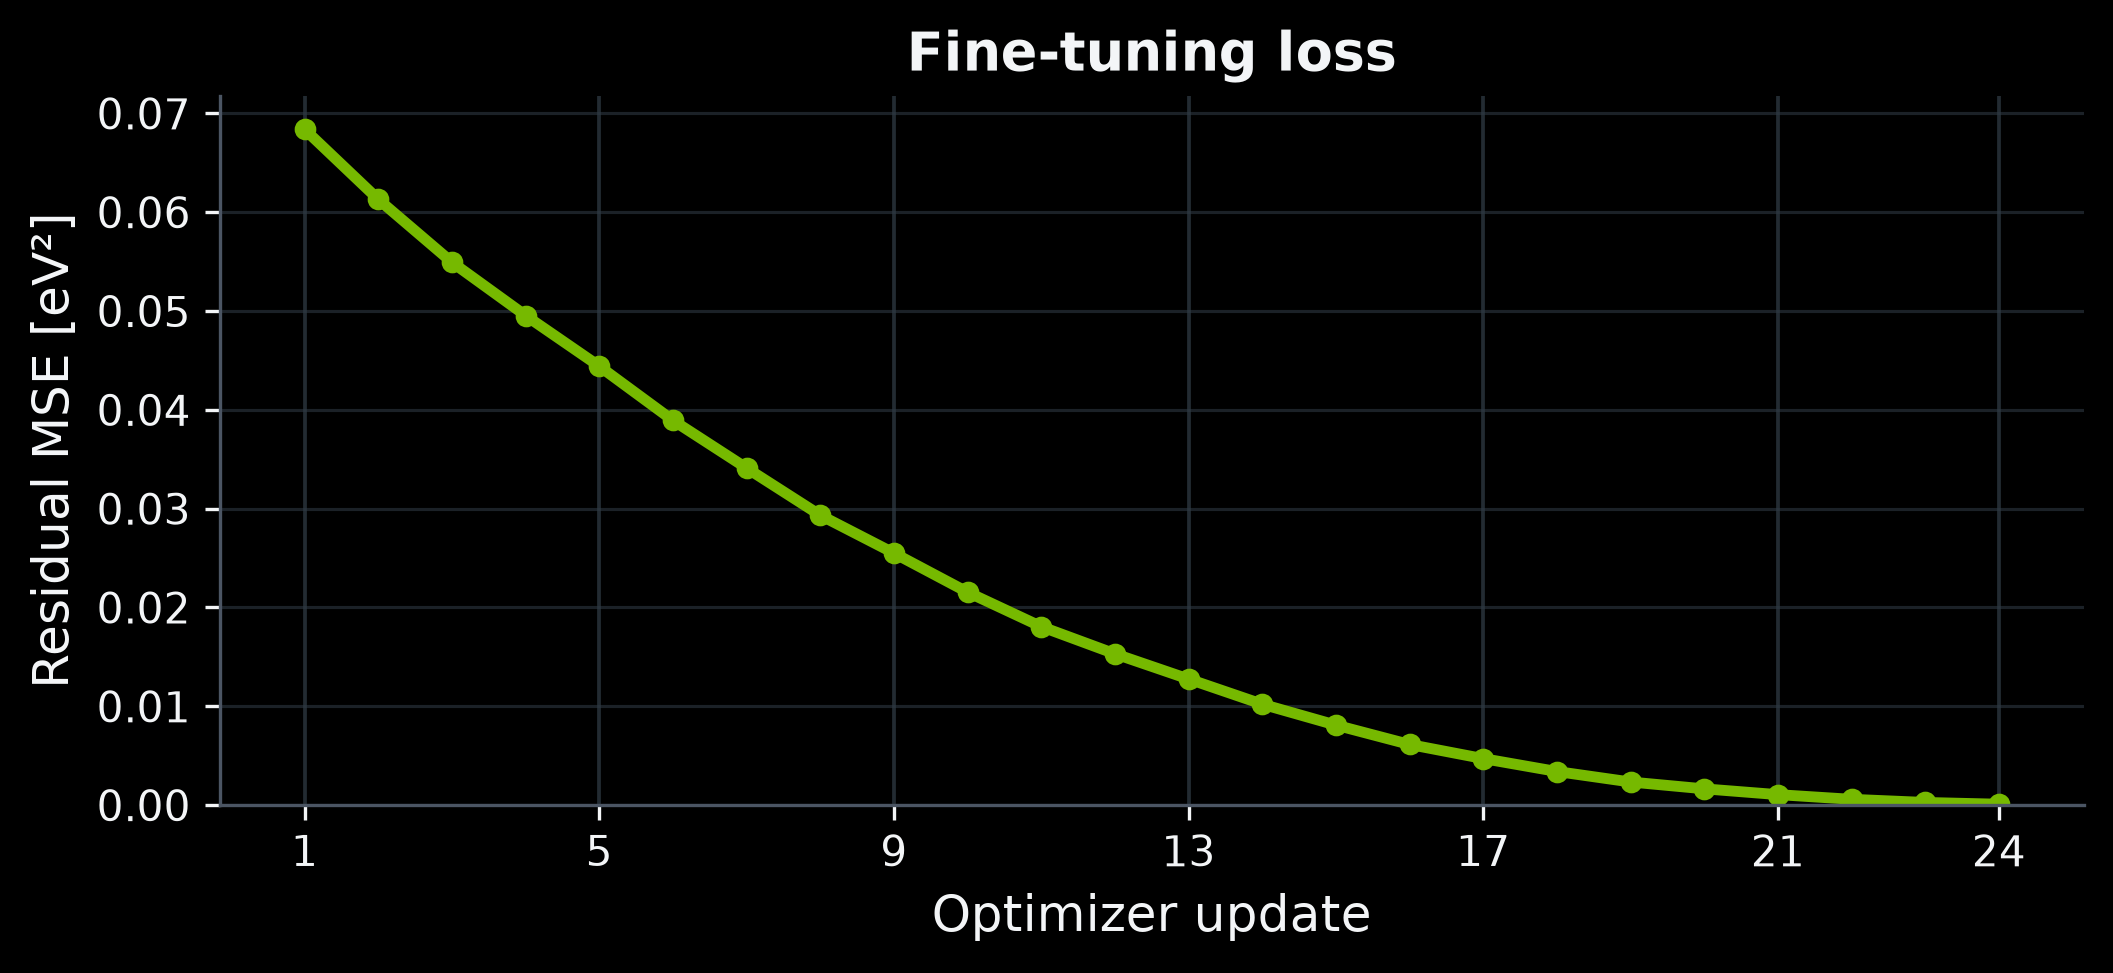

In [ ]:
helpers.plot_lj_finetuning_loss(loss_history.rows)

### Isolate the fitted interaction in an Ar₂ scan

Each periodic Ar₂₇ energy above is a sum of many Ar-Ar pair energies. The fitted ε scales every pair term.

The next cells build 81 nonperiodic Ar₂ systems spanning 3.25 to 6.50 Å. They use the same σ, cutoff, baseline, and correction as the Ar₂₇ calculation. The pair systems show the fitted interaction directly; the 64 perturbed Ar₂₇ structures provide the held-out metric.

**Question:** How closely does the fine-tuned pair energy follow exact LJ across distance?

In [ ]:
pair_distance = torch.linspace(3.25, 6.50, 81, device=device)
pair_batch = helpers.build_argon_pair_curve(pair_distance)
compute_neighbors(pair_batch, config=lj_model.model_config.neighbor_config)

In [ ]:
with torch.no_grad():
    exact_curve = lj_model(pair_batch)["energy"]
    baseline_curve = baseline_lj(pair_batch)["energy"]
    unit_curve = correction_wrapper.unit_lj(pair_batch)["energy"]
    # Reconstruct the composed model before fine-tuning.
    initial_curve = baseline_curve + initial_epsilon * unit_curve
    fine_tuned_curve = composed_lj(pair_batch)["energy"]


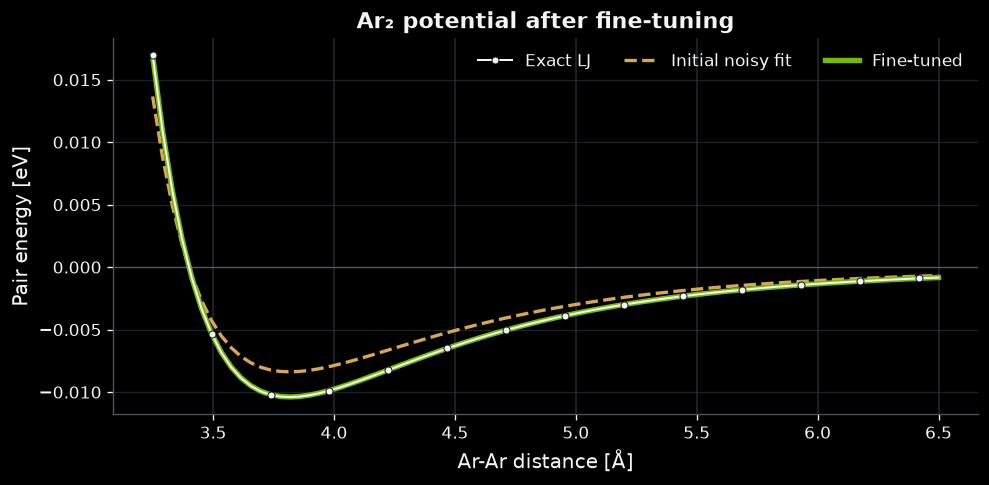

In [ ]:
helpers.plot_lj_transfer_curve(
    pair_distance,
    exact_curve,
    initial_curve,
    fine_tuned_curve,
)

White markers show exact LJ. Amber shows the initial noisy fit. Green shows the same composed model after `FineTuningStrategy`. The fitted ε moves the pair energy toward the exact curve across the scan.

The Ar₂ scan explains what the fitted scalar controls. The held-out Ar₂₇ MAE above measures performance on unseen 27-atom geometries.

**Scope:** Exact LJ supplies the controlled reference. Part 07 develops multi-output losses, validation splits, checkpointing, and reference data from electronic-structure calculations.

**Go deeper:** <span class="alchemi-in-progress">Part 07 · Training and fine-tuning · in progress</span>. The [official fine-tuning guide](https://nvidia.github.io/nvalchemi-toolkit/userguide/finetuning.html) covers trainable parameter selection, validation, checkpointing, and restartable workflows.

### Preview domain parallelism in one process

**Switching gears:** This preview builds one new periodic acetamide-benzene system to introduce spatial decomposition. `AtomicData`, `Batch`, AIMNet2, and `BaseDynamics` carry forward; workload ownership changes from many independent structures to spatial partitions of one graph.

Follow the public sequence used in a distributed launch: initialize, configure, partition, run, gather, and clean up. This one-process walkthrough keeps every atom on rank 0. Part 08 develops the multi-rank calculation.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> ```python
> with DomainParallel(dynamics=inner, config=config) as domain:
>     local = domain.partition(batch)
>     local = domain.run(local)
>     result = domain.gather(local, dst=0)
> ```
>
> **Input:** one global `Batch`, an inner dynamics object, and domain configuration  
> **Result:** rank-local spatial work plus a gathered global result on the destination rank

In [ ]:
domain_atoms = atoms[1].copy()
domain_partner = molecule("C6H6")
# Separate the molecules by 9 Å inside a 30 Å periodic control cell.
domain_partner.positions += (9.0, 0.0, 0.0)
domain_atoms += domain_partner
domain_atoms.set_cell((30.0, 30.0, 30.0))
domain_atoms.center()
domain_atoms.set_pbc(True)

In [ ]:
domain_graph = AtomicData.from_atoms(domain_atoms, device=device)
domain_graph.add_system_property("charge", torch.zeros((1, 1), device=device))
# Add empty energy and force fields for DomainParallel to update and gather.
domain_graph.add_system_property("energy", torch.zeros((1, 1), device=device))
domain_batch = Batch.from_data_list([domain_graph], device=device)
domain_batch.add_key(
    "forces", [torch.zeros_like(domain_graph.positions)],
    level="node", overwrite=True,
)

In [ ]:
# Match the model cutoff; zero skin uses that exact radius.
# mesh=None selects the single-rank path. grid_dims defaults to None,
# so SpatialPartitioner derives the spatial grid.
domain_config = DomainConfig(
    cutoff=float(model.model_config.neighbor_config.cutoff),
    skin=0.0,
    mesh=None,
    compile=False,
)

In [ ]:
DistributedManager.initialize()
manager = DistributedManager()
world_size = manager.world_size
DOMAIN_STEPS = 1  # One model step exercises the domain control path.
# BaseDynamics hosts model evaluation and neighbor hooks inside DomainParallel.
domain_evaluator = BaseDynamics(
    model=model, n_steps=DOMAIN_STEPS, hooks=model.make_neighbor_hooks()
)

/tmp/alchemi-v3-runtime/venv/lib/python3.12/site-packages/physicsnemo/distributed/manager.py:415: UserWarning: Could not initialize using ENV, SLURM or OPENMPI methods. Assuming this is a single process job
  warn(


In [ ]:
try:
    with DomainParallel(
        dynamics=domain_evaluator,
        config=domain_config,
        n_steps=DOMAIN_STEPS,
        device_type=device.type,
    ) as domain:
        # partition assigns owned atoms, run evaluates them, and gather rebuilds rank 0.
        owned_batch = domain.partition(domain_batch)
        domain_result = domain.run(owned_batch, n_steps=DOMAIN_STEPS)
        gathered_result = domain.gather(domain_result, dst=0)
finally:
    DistributedManager.cleanup()

INFO:nvalchemi.distributed._core.shard_wrappers:Registered 21 passthrough + 8 reduction ShardTensor wrappers


In [ ]:
print("world size:       ", world_size)
print("input atoms:      ", domain_batch.num_nodes)
print("rank-0 owned atoms:", int(owned_batch.positions.shape[0]))
print("gathered atoms:   ", int(gathered_result.positions.shape[0]))
print("gathered type:    ", type(gathered_result).__name__)

world size:        1
input atoms:       21
rank-0 owned atoms: 21
gathered atoms:    21
gathered type:     Batch


**Scope:** World size one exercises initialization, `partition`, `run`, `gather`, and cleanup while rank 0 owns every atom. Multi-rank work adds a device mesh, rank-owned input, derived grid settings, and energy and force parity before timing.

**Go deeper:** <span class="alchemi-in-progress">Part 08 · Domain decomposition · in progress</span>. The [official distributed simulations guide](https://nvidia.github.io/nvalchemi-toolkit/userguide/distributed.html) explains device meshes, partitioning, halo exchange, and launch requirements.

### Read a rank as one worker

The distributed examples start one process per GPU. Toolkit numbers those processes `0`, `1`, and so on. Each process number is a **rank**.

`DistributedPipeline` maps each rank to one workflow stage. For `FIRE2 | NVE`, rank 0 runs FIRE2. When a system finishes FIRE2, its `Batch` payload moves to rank 1, which runs NVE. Graph and atom counts describe the `Batch`. The rank identifies the process running the current stage.

`DomainParallel` uses ranks for spatial ownership. Every rank works on a partition of one large graph. `gather(..., dst=0)` rebuilds the atom fields on rank 0.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `pipeline = stage_a | stage_b`
>
> **Input:** two workflow stages in execution order  
> **Result:** a `DistributedPipeline` with `stage_a` on rank 0 and `stage_b` on rank 1

In [ ]:
pipeline_preview = (
    FIRE2(model=model, dt=0.01, maxstep=0.04, n_steps=2)
    | NVE(model=model, dt=0.25, n_steps=2)
)
for rank, stage in pipeline_preview.stages.items():
    print(f"rank {rank} owns {type(stage).__name__}")

This preview builds the rank-to-stage map. A distributed run launches two worker processes with `torchrun`, typically one rank per CUDA GPU, and calls `pipeline.run()`. Each process reads its rank and executes its assigned stage.

### Distinguish the scaling APIs

A `Batch` is the container. Each molecule or structure inside it is one atomic system, represented as one graph in Toolkit storage. The table uses **system** for that scientific unit.

| API | What changes during execution | Data being processed |
|---|---|---|
| `Batch` | The set of systems stays fixed for one model call | One `Batch` containing several systems |
| `FusedStage` | Each system's `status` selects its current workflow stage | The same active `Batch` across stages |
| Inflight batching | Completed systems leave and the sampler inserts waiting systems | An active `Batch` that is repeatedly refilled |
| `DistributedPipeline` | `Batch` payloads move between rank-owned stages | Independent systems packed into transfer batches |
| `DomainParallel` | Ranks own spatial regions and exchange halo atoms | One large system partitioned across ranks, typically one CUDA GPU per rank |

The FusedStage and inflight diagrams above show the two changing-state cases. See the official [distributed examples](https://nvidia.github.io/nvalchemi-toolkit/examples/distributed/index.html) for complete multi-process launches.

### Hypothetical four-GPU domain run

A four-process launch gives each rank a spatial region of the same periodic graph. Rank 0 supplies the global `Batch`; the other ranks call `partition(None)`. Every rank then runs the same model and dynamics step on its local `Batch`.

```text
global Batch on rank 0
          |
     partition(...)
          |
+-------------------+-------------------+
| rank 0            | rank 1            |
| owned atoms       | owned atoms       |
+-------------------+-------------------+
| rank 2            | rank 3            |
| owned atoms       | owned atoms       |
+-------------------+-------------------+
      <---- halo exchange ---->
          |
 domain.run(local_batch) on every rank
          |
   gather(..., dst=0)
          |
global result on rank 0
```

Halo exchange supplies neighboring atoms across region boundaries before model evaluation. The drawing is a two-dimensional slice through the periodic cell. `SpatialPartitioner` derives the actual three-dimensional regions from the cell, cutoff, and rank count.

| Setup | Input to `partition(...)` | Ownership during `run(...)` |
|---|---|---|
| This notebook, 1 rank | rank 0 passes `domain_batch` | rank 0 owns the full graph |
| Hypothetical, 4 ranks | rank 0 passes `domain_batch`; ranks 1–3 pass `None` | each rank owns one spatial region |

Part 08 will report owned and halo atom counts from an actual multi-GPU launch.

> 💡 A rank is one distributed worker. `DistributedPipeline` assigns one stage to each rank and sends independent graphs between ranks. `DomainParallel` assigns one spatial partition of the same graph to each rank.

<hr class="alchemi-section-divider" aria-hidden="true" style="border:0;border-top:1px solid #D6D9D4;margin:2.4rem 0 1rem;">

## 09 · Recap and next steps

The same objects now form a complete route from scientific structure to saved simulation state.

### What we learned

- `AtomicData` stores one structure as tensors with explicit field ownership.
- `Batch` packs unequal structures and records their atom-row boundaries.
- `Reader → Dataset → DataLoader` turns stored records back into model batches.
- Model wrappers declare inputs, outputs, neighbors, and devices.
- Hooks observe and control named workflow stages.
- `FIRE2`, `NVE`, and `FusedStage` update batched simulation state.

### How we will use it

Later notebooks keep this route and deepen one part at a time: storage, model composition, hooks, dynamics, GPU execution, training, or distributed ownership.

### Choose what to study next - Deev Dives [...in development...]

- <span class="alchemi-in-progress">Part 01 · AtomicData and Batch · in progress</span>: conversion, fields, validation, and batch operations.
- <span class="alchemi-in-progress">Part 02 · Zarr data loading · in progress</span>: persistent records and model-ready loading.
- <span class="alchemi-in-progress">Parts 03–05 · Models, hooks, and BaseDynamics · in progress</span>: build and control simulation workflows.
- <span class="alchemi-in-progress">Parts 06–08 · GPU pipelines, training, and domain decomposition · in progress</span>.

### Resources and acknowledgements

Keep the [Toolkit user guides](https://nvidia.github.io/nvalchemi-toolkit/userguide/index.html) and [examples gallery](https://nvidia.github.io/nvalchemi-toolkit/examples/) nearby when adapting this playbook.

Thanks to the NVIDIA ALCHEMI team and the contributors who shaped this course, with special thanks to Kelvin Lee, Roman Zubatyuk and Ryan Reese. 